Airbnb Price Prediction with ML — Final Merged Pipeline From Chrysa's and Huan's Pipelines
==================================================================================
Combines the best of two piplines:
  - Full 5-source data assembly + LLM spatial_semantics 
  - Leakage-free imputation: sentiment/review medians computed post-split 
  - Binary flag mode-imputation, continuous KNN-imputation (new fix applied to both)
  - GridSearchCV for ENet + RF, Hyperopt Bayesian search for XGBoost and LightGBM (best of both)
  - 11 models + averaged ensemble including BayesianRidge 
  - Feature importance chart coloured by core IV vs control 
  - Full results CSV + all plots saved 
  - All-models predictions vs actuals plot


In [ ]:
import warnings
import os
import logging

warnings.filterwarnings("ignore")
os.environ["PYTHONWARNINGS"] = "ignore"

print("Warning suppression active")

Warning suppression active


In [ ]:
import warnings
import os
import logging

# Suppress all warnings globally
warnings.filterwarnings("ignore")
os.environ["PYTHONWARNINGS"] = "ignore"

print("Warning suppression active")

Warning suppression active


In [ ]:
pip install setuptools --upgrade


Note: you may need to restart the kernel to use updated packages.


In [ ]:
# For pkg_resources compatibility shim (Python 3.12+) 
import importlib.metadata
import importlib.resources
import sys
try:
    import pkg_resources
except ImportError:
    import types
    pkg_resources = types.ModuleType("pkg_resources")
    pkg_resources.get_distribution = lambda name: type(
        "D", (), {"version": importlib.metadata.version(name)}
    )()
    sys.modules["pkg_resources"] = pkg_resources

In [ ]:
pip install hyperopt geopandas pyproj libpysal esda spreg splot --break-system-packages

Note: you may need to restart the kernel to use updated packages.


In [ ]:
# import necessary packages
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
import geopandas as gpd
import seaborn as sns
import matplotlib.patches as mpatches
import contextily as ctx
import pyproj
import xgboost as xgb
import lightgbm as lgb
import os

from datetime import datetime
from libpysal.weights import DistanceBand, KNN
from esda.moran import Moran
from spreg import OLS, ML_Error, ML_Lag, GM_Error, GM_Lag
from scipy import stats
from shapely.geometry import Point
from splot.esda import moran_scatterplot, plot_moran
from matplotlib.ticker import FuncFormatter
from libpysal.weights import lag_spatial
from scipy.stats import norm
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestRegressor
from scipy.spatial.distance import cdist
from sklearn.metrics import pairwise_distances
from sklearn.linear_model import BayesianRidge
from sklearn.metrics import mean_squared_error, r2_score
warnings.filterwarnings("ignore")

from sklearn.model_selection import (
    train_test_split, KFold, cross_val_score,
    GridSearchCV
)

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.impute import KNNImputer
from sklearn.preprocessing import RobustScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import Lasso, ElasticNet, BayesianRidge
from sklearn.kernel_ridge import KernelRidge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.base import BaseEstimator, RegressorMixin, TransformerMixin, clone
from hyperopt import STATUS_OK, Trials, fmin, hp, tpe
from sklearn.preprocessing import LabelEncoder 

from numpy.random import default_rng

Data sources
------------
  listings_cleaned_keer.csv            → main table, log_price + control vars

  202410_listings_with_gender_Cong.csv → gender_final

  202410_listings_with_POIbuffer_Cong.csv → POI counts

  airbnb_sentiment_results_ml.csv      → average_sentiment, review_count
  
  inference_Qwen3_COMBINED.json        → spatial_semantics (LLM output) <---THIS FILE NEEDS TO BE PROCESSED FURTHER BEFORE BEING USED AS AN INPUT

# Processing the raw json files to fit for the purpose 
**The original raw files count per month stricitly only the listings that appear for first time on October 2024 (149 records) but exclude all lisitngs which are still active during the selected month (October 2024) but their distription was created previously.**

We need to fix it so the produced file (of spatial semantics) keeps all records scraped on any date up to 18 October 2024.  This picks the single most recent record per listing. See scnario below:

in the follwosing scenario:

Listing 12345 scrape history:
  2021-02-12  → "A cosy flat near Leith Walk"           (original)
  2023-06-15  → "A stunning flat near Leith and the Shore" (edit 1)
  2024-09-13  → "Modern flat steps from Leith Walk, Portobello nearby" (edit 2)

  The February 2021 and June 2023 versions are permanently discarded in the final csv. 

  Additionally, we need to ensure that per lisitng we avoid duplicated counting, and **only unique locations** are counted as a score.

In [ ]:
PATH_CLEANED = "/Users/xrysa/Desktop/MSc_in_Urban_Analytics/Group_Project/Airbnb-Performace-Pridiction-using-LLM-derived-Spatial-Semantics-main/prediction/Data/listings_cleaned_keer.csv"

LLM_JOBS = [
    {
        "label":     "qwen_desc",
        "json_path": "/Users/xrysa/Desktop/MSc_in_Urban_Analytics/Group_Project/Airbnb-Performace-Pridiction-using-LLM-derived-Spatial-Semantics-main/prediction/Data/inference_Qwen3_DESCRIPTION_ONLY.json"
    },
    {
        "label":     "qwen_combined",
        "json_path": "/Users/xrysa/Desktop/MSc_in_Urban_Analytics/Group_Project/Airbnb-Performace-Pridiction-using-LLM-derived-Spatial-Semantics-main/prediction/Data/inference_Qwen3_COMBINED.json"
    },
    {
        "label":     "nemo_desc",
        "json_path": "/Users/xrysa/Desktop/MSc_in_Urban_Analytics/Group_Project/Airbnb-Performace-Pridiction-using-LLM-derived-Spatial-Semantics-main/prediction/Data/inference_NEMO_DESCRIPTION_ONLY.json"
    },
]

In [ ]:
CUTOFF_DATE = "2024-10-18"
# Load id and neighborhood_overview from cleaned CSV
# description comes from JSON — not loaded here

cleaned = pd.read_csv(PATH_CLEANED, usecols=["id", "description", "neighborhood_overview"])
cleaned["id"] = cleaned["id"].astype(str)

Step 1 — match by id (original)
        → 4189 matched / 5138

Step 2 — for the 949 unmatched, try exact description text match
        → recover some listings where id was lost but text is identical

Step 3 — report how many were recovered
        → improvement over id-only matching

Step 4 — fill remaining truly unmatched with 0

In [ ]:
#Normalise text for matching, i.e., lowercase, strip whitespace
def normalise_text(s):
    if pd.isna(s) or str(s).strip() == "":
        return ""
    return str(s).lower().strip()

cleaned["desc_norm"] = cleaned["description"].apply(normalise_text)
cleaned["desc_neigh_norm"] = (
    cleaned["description"].apply(normalise_text) + " " +
    cleaned["neighborhood_overview"].apply(normalise_text)
).str.strip()

print(f"Cleaned pool: {len(cleaned)} listings")
print(f"  With description          : {(cleaned['desc_norm'] != '').sum()}")
print(f"  With description + neighb : {(cleaned['desc_neigh_norm'] != '').sum()}")


Cleaned pool: 5138 listings
  With description          : 5052
  With description + neighb : 5085


## Matching has been done by two ways: Match 1: by id and Match 2: by description text

Currently 18.5% of listings (949) get spatial_semantics = 0 because their id does not match any record in the JSON. But the LLM may have actually processed those listings' descriptions so the id just did not survive the join. If we match on description text instead, we can potentially recover a large portion of those 949 unmatched listings.

In [ ]:
for job in LLM_JOBS:
    print(f"── {job['label']} ──")

    # Check file exists
    if not os.path.exists(job["json_path"]):
        print(f"  File not found: {job['json_path']} — skipping\n")
        continue

    # Load JSON
    with open(job["json_path"], "r") as f:
        llm_raw = json.load(f)

    print(f"  Total JSON records : {len(llm_raw)}")

    # Build flat dataframe — set() ensures unique locations only
    llm_df = pd.DataFrame([{
        "id":        str(r["id"]),
        "scraped":   r.get("scraped", ""),
        "desc_norm": normalise_text(r.get("description", "")),
        "spatial_semantics": len(set(
            [s.lower().strip() for s in r.get("specific_locations", [])] +
            [s.lower().strip() for s in r.get("general_references",  [])]
        )),
        "n_specific": len(set(
            [s.lower().strip() for s in r.get("specific_locations", [])]
        )),
        "n_general": len(set(
            [s.lower().strip() for s in r.get("general_references", [])]
        )),
    } for r in llm_raw])

    # Filter to pre-cutoff records

    llm_df_filtered = llm_df[llm_df["scraped"] <= CUTOFF_DATE].copy()
    print(f"  Records before cutoff ({CUTOFF_DATE}): {len(llm_df_filtered)}")

    # Verify date range
    DATE_START = "2024-10-01"
    DATE_END   = "2024-10-31"
    print(f"  Date range of filtered records:")
    print(f"    Earliest : {llm_df_filtered['scraped'].min()}")
    print(f"    Latest   : {llm_df_filtered['scraped'].max()}")
    outside = llm_df_filtered[
        (llm_df_filtered["scraped"] < DATE_START) |
        (llm_df_filtered["scraped"] > DATE_END)
    ]
    if len(outside) == 0:
        print(f"    All records within October 2024")
    else:
        print(f"    {len(outside)} records outside Oct 2024 — expected, cutoff uses all pre-{CUTOFF_DATE} snapshots")

    # Keep latest record per listing before cutoff
    llm_latest = (
        llm_df_filtered.sort_values("scraped")
                       .groupby("id", as_index=False)
                       .last()
    )
    print(f"  Unique listings after dedup: {len(llm_latest)}")

    # ── Match 1: by id ──
    merged_id = cleaned[["id", "desc_norm"]].merge(
        llm_latest[["id", "scraped", "spatial_semantics",
                    "n_specific", "n_general"]],
        on="id", how="left"
    )
    matched_by_id = merged_id["spatial_semantics"].notna().sum()
    print(f"  Matched by id              : {matched_by_id} / {len(cleaned)}")

    # ── Match 2: by description text ──
    llm_desc_lookup = (
        llm_latest[llm_latest["desc_norm"] != ""]
        .drop_duplicates(subset=["desc_norm"], keep="last")
        .set_index("desc_norm")[["spatial_semantics", "n_specific", "n_general"]]
    )

    unmatched_mask  = merged_id["spatial_semantics"].isna()
    unmatched_descs = merged_id.loc[unmatched_mask, "desc_norm"]

    recovered_sem = unmatched_descs.map(llm_desc_lookup["spatial_semantics"])
    recovered_spe = unmatched_descs.map(llm_desc_lookup["n_specific"])
    recovered_gen = unmatched_descs.map(llm_desc_lookup["n_general"])

    n_recovered = recovered_sem.notna().sum()
    print(f"  Recovered by description   : {n_recovered}")

    merged_id.loc[unmatched_mask, "spatial_semantics"] = recovered_sem.values
    merged_id.loc[unmatched_mask, "n_specific"]        = recovered_spe.values
    merged_id.loc[unmatched_mask, "n_general"]         = recovered_gen.values

    still_unmatched = merged_id["spatial_semantics"].isna().sum()
    print(f"  Still unmatched after desc : {still_unmatched}")

    # Fill remaining with 0
    merged_id["spatial_semantics"] = merged_id["spatial_semantics"].fillna(0).astype(int)
    merged_id["n_specific"]        = merged_id["n_specific"].fillna(0).astype(int)
    merged_id["n_general"]         = merged_id["n_general"].fillna(0).astype(int)
    merged_id["llm_processed"]     = (
        (merged_id["spatial_semantics"] > 0) |
        merged_id["id"].isin(llm_latest["id"])
    ).astype(int)

    # Summary stats
    total_matched = int(merged_id["llm_processed"].sum())
    n_missing     = len(merged_id) - total_matched
    n_true_zero   = int(((merged_id["spatial_semantics"] == 0) &
                         (merged_id["llm_processed"] == 1)).sum())
    stats         = merged_id["spatial_semantics"].describe()

    print(f"  Total matched (id + desc)  : {total_matched} / {len(cleaned)}"
          f" ({total_matched/len(cleaned)*100:.1f}%)")
    print(f"  Improvement over id-only   : +{total_matched - matched_by_id} listings")
    print(f"  Unmatched (filled with 0)  : {n_missing}")
    print(f"  True zeros (LLM ran, 0 loc): {n_true_zero}")
    print(f"  Mean / Median / Max        : {stats['mean']:.2f} / "
          f"{stats['50%']:.0f} / {stats['max']:.0f}")

    # Drop desc_norm before saving
    merged_id.drop(columns=["desc_norm"], inplace=True)

    # Build output path in same folder as JSON
    json_dir      = os.path.dirname(os.path.abspath(job["json_path"]))
    json_basename = os.path.splitext(os.path.basename(job["json_path"]))[0]
    out_path      = os.path.join(
        json_dir,
        f"spatial_semantics_{job['label']}_from_{json_basename}_textmatch_unique.csv"
    )
    merged_id.to_csv(out_path, index=False)
    print(f"  Saved: {out_path}\n")
    print("─" * 55)

print("Done.")

── qwen_desc ──
  Total JSON records : 37058
  Records before cutoff (2024-10-18): 32009
  Date range of filtered records:
    Earliest : 2020-12-19
    Latest   : 2024-10-18
    31863 records outside Oct 2024 — expected, cutoff uses all pre-2024-10-18 snapshots
  Unique listings after dedup: 15011
  Matched by id              : 4189 / 5138
  Recovered by description   : 0
  Still unmatched after desc : 949
  Total matched (id + desc)  : 4189 / 5138 (81.5%)
  Improvement over id-only   : +0 listings
  Unmatched (filled with 0)  : 949
  True zeros (LLM ran, 0 loc): 327
  Mean / Median / Max        : 4.35 / 4 / 26
  Saved: /Users/xrysa/Desktop/MSc_in_Urban_Analytics/Group_Project/Airbnb-Performace-Pridiction-using-LLM-derived-Spatial-Semantics-main/prediction/Data/spatial_semantics_qwen_desc_from_inference_Qwen3_DESCRIPTION_ONLY_textmatch_unique.csv

───────────────────────────────────────────────────────
── qwen_combined ──
  Total JSON records : 38024
  Records before cutoff (2024-10-1

In [ ]:
llm_latest.shape

(15011, 6)

## Report summary comparison across all 4 jobs 

In [ ]:
print("\n" + "=" * 100)
print(f"  {'Job':<20} {'Total':>6} {'Matched':>8} {'Pct':>6} "
      f"{'Unmatched':>10} {'Pct':>6} {'TrueZero':>9} "
      f"{'Mean':>6} {'Median':>7} {'Max':>5}")
print("  " + "─" * 98)

for job in LLM_JOBS:
    json_dir      = os.path.dirname(os.path.abspath(job["json_path"]))
    json_basename = os.path.splitext(os.path.basename(job["json_path"]))[0]
    out_filename = f"spatial_semantics_{job['label']}_from_{json_basename}_textmatch_unique.csv"
    out_path      = os.path.join(json_dir, out_filename)

    if not os.path.exists(out_path):
        print(f"  {job['label']:<20} — file not found")
        continue

    df          = pd.read_csv(out_path)
    total       = len(df)
    n_matched   = int(df["llm_processed"].sum())
    n_missing   = total - n_matched
    n_true_zero = int(((df["spatial_semantics"] == 0) & (df["llm_processed"] == 1)).sum())
    stats       = df["spatial_semantics"].describe()

    print(f"  {job['label']:<20} {total:>6} {n_matched:>8} "
          f"{n_matched/total*100:>5.1f}% {n_missing:>10} "
          f"{n_missing/total*100:>5.1f}% {n_true_zero:>9} "
          f"{stats['mean']:>6.2f} {stats['50%']:>7.0f} {stats['max']:>5.0f}")

print("=" * 100)


  Job                   Total  Matched    Pct  Unmatched    Pct  TrueZero   Mean  Median   Max
  ──────────────────────────────────────────────────────────────────────────────────────────────────
  qwen_desc              5138     4189  81.5%        949  18.5%       327   4.35       4    26
  qwen_combined          5138     4211  82.0%        927  18.0%       255   5.61       5    26
  nemo_desc              5138     4189  81.5%        949  18.5%      1804   1.42       0    17


In [ ]:
# File Paths  , CAUTION have to EDIT THESE
PATH_CLEANED   = "/Users/xrysa/Desktop/MSc_in_Urban_Analytics/Group_Project/Airbnb-Performace-Pridiction-using-LLM-derived-Spatial-Semantics-main/prediction/Data/listings_cleaned_keer.csv"
PATH_GENDER    = "/Users/xrysa/Desktop/MSc_in_Urban_Analytics/Group_Project/Airbnb-Performace-Pridiction-using-LLM-derived-Spatial-Semantics-main/prediction/Data/202410_listings_with_gender_Cong.csv"
PATH_POI       = "/Users/xrysa/Desktop/MSc_in_Urban_Analytics/Group_Project/Airbnb-Performace-Pridiction-using-LLM-derived-Spatial-Semantics-main/prediction/Data/202410_listings_with_POIbuffer_Cong.csv"
PATH_SENTIMENT = "/Users/xrysa/Desktop/MSc_in_Urban_Analytics/Group_Project/Airbnb-Performace-Pridiction-using-LLM-derived-Spatial-Semantics-main/prediction/Data/airbnb_sentiment_results_ml.csv"
PATH_LLM_csv_combined = "/Users/xrysa/Desktop/MSc_in_Urban_Analytics/Group_Project/Airbnb-Performace-Pridiction-using-LLM-derived-Spatial-Semantics-main/prediction/Data/spatial_semantics_qwen_combined_from_inference_Qwen3_COMBINED_textmatch_unique.csv"
PATH_LLM_csv_description_only = "/Users/xrysa/Desktop/MSc_in_Urban_Analytics/Group_Project/Airbnb-Performace-Pridiction-using-LLM-derived-Spatial-Semantics-main/prediction/Data/spatial_semantics_qwen_desc_from_inference_Qwen3_DESCRIPTION_ONLY_textmatch_unique.csv"

### Checking 

In [ ]:
# NOTE: this cell must be run immediately after Cell 12 (the LLM processing loop)
# llm_df_filtered holds only the LAST job processed (nemo_desc)
# For per-job date ranges see the output printed inside the loop above

# Verify the date range of filtered records
DATE_START = "2024-10-01"
DATE_END   = "2024-10-31"

print("Date range of filtered records:")
print(f"  Earliest: {llm_df_filtered['scraped'].min()}")
print(f"  Latest  : {llm_df_filtered['scraped'].max()}")

# Confirm no dates outside the selected range slipped through
outside = llm_df_filtered[
    (llm_df_filtered["scraped"] < DATE_START) |
    (llm_df_filtered["scraped"] > DATE_END)
]
print(f"  Records outside {DATE_START} to {DATE_END}: {len(outside)}")
if len(outside) == 0:
    print(f"  All records within range")
else:
    print(f"  ⚠ {len(outside)} records found outside range")
    #print(outside["scraped"].value_counts().to_string())

Date range of filtered records:
  Earliest: 2020-12-19
  Latest  : 2024-10-18
  Records outside 2024-10-01 to 2024-10-31: 31863
  ⚠ 31863 records found outside range


In [ ]:
# Load all CSV sources
print("\n Loading CSVs")
cleaned   = pd.read_csv(PATH_CLEANED)
n_raw_listings = len(cleaned)   # correct, captures full 5138 here
gender    = pd.read_csv(PATH_GENDER)[["id", "gender_final"]]
poi       = pd.read_csv(PATH_POI)[[
    "id", "Total_POI_500m", "Total_POI_800m", "Total_POI_1500m"
]]
sentiment = (
    pd.read_csv(PATH_SENTIMENT)
    .rename(columns={"listing_id": "id"})
    [["id", "average_sentiment", "review_count"]]
)
llm = pd.read_csv(PATH_LLM_csv_combined)[[
    "id", "spatial_semantics", "n_specific", "n_general", "llm_processed"
]]

# Consistent id dtype across all sources
for frame in [cleaned, gender, poi, sentiment, llm]:
    frame["id"] = frame["id"].astype(str)

print(f"  cleaned  : {len(cleaned):>6} rows")
print(f"  gender   : {len(gender):>6} rows")
print(f"  poi      : {len(poi):>6} rows")
print(f"  sentiment: {len(sentiment):>6} rows")
print(f"  llm      : {len(llm):>6} rows")


 Loading CSVs
  cleaned  :   5138 rows
  gender   :   5629 rows
  poi      :   5629 rows
  sentiment:   4689 rows
  llm      :   5138 rows


# Data Transformation

In [ ]:
#  Changing Room type into a categorical variable
if "room_type" in cleaned.columns and "room_type_code" not in cleaned.columns:
    cleaned["room_type"] = cleaned["room_type"].astype(str)
    lbl = LabelEncoder()
    cleaned["room_type_code"] = lbl.fit_transform(cleaned["room_type"])
    print("\n  room_type encoded → room_type_code")
cleaned['room_type'].value_counts()

room_type
Entire home/apt    3502
Private room       1601
Shared room          22
Hotel room           13
Name: count, dtype: int64

In [ ]:
# shape
print('Shape cleaned: {}'.format(cleaned.shape))

Shape cleaned: (5138, 108)


#  Merge all sources of independent variables on id (of each listing)

In [ ]:
df = (
    cleaned
    .merge(gender,    on="id", how="left")
    .merge(poi,       on="id", how="left")
    .merge(sentiment, on="id", how="left")
    .merge(llm, on="id", how="left")
)

print(f"  Merged df shape           : {df.shape}")
print(f"  Missing spatial_sem.   : {df['spatial_semantics'].isnull().sum()} → filling with 0")
print(f"  Missing average_sentiment: {df['average_sentiment'].isnull().sum()} → filling with median")
print(f"  Missing review_count:      {df['review_count'].isnull().sum()} → filling with median")

# spatial_semantics: 0 means no LLM-detected references, not a data gap
# (listings with no LLM output are a small fraction — flagged in console above)
df["spatial_semantics"] = df["spatial_semantics"].fillna(0).astype(int)

# NOTE average_sentiment and review_count are NOT filled here.
# They will be filled post-split using train-set medians to prevent leakage.

  Merged df shape           : (5138, 118)
  Missing spatial_sem.   : 0 → filling with 0
  Missing average_sentiment: 865 → filling with median
  Missing review_count:      865 → filling with median


## Critical point
New listings (zero reviews) should be excluded because their prices are not set based on market feedback.  New listings have aspirational prices not validated by market feedback. Therefore, these are not comparable to established listings globally, only locally. Their review_count=0 makes sentiment scores meaningless and price comparability questionable globally (see Zervas et al. 2017; Gunter & Önder 2018).This is a standard cleaning step in Airbnb hedonic pricing research.

In [ ]:
# Drop listings with no reviews (new listings) 
before = len(df)
df = df[df["review_count"].isna() | (df["review_count"] > 0)].copy()
after  = len(df)

# The condition review_count > 0 evaluates NaN as False, so NaN rows are dropped along with zero-review rows. 
# This means we are dropping 865 listings with no sentiment data in addition to the intended zero-review drop. 
# The printout will show the correct number dropped but for the wrong reason. This why I replaced df = df[df["review_count"] > 0].copy()

print(f"  Listings before dropping no-review: {before}")
print(f"  Listings with zero reviews dropped : {before - after}")
print(f"  Listings remaining                 : {after}")
print(f"  Median review_count (remaining)    : {df['review_count'].median():.0f}")

  Listings before dropping no-review: 5138
  Listings with zero reviews dropped : 0
  Listings remaining                 : 5138
  Median review_count (remaining)    : 59


In [ ]:
print(df.shape)
print(df.columns)

(5138, 118)
Index(['id', 'listing_url', 'scrape_id', 'last_scraped', 'source', 'name',
       'description', 'neighborhood_overview', 'picture_url', 'host_id',
       ...
       'gender_final', 'Total_POI_500m', 'Total_POI_800m', 'Total_POI_1500m',
       'average_sentiment', 'review_count', 'spatial_semantics', 'n_specific',
       'n_general', 'llm_processed'],
      dtype='str', length=118)


### Checking for missing values

In [ ]:
# Prints a clean missing value report for any dataframe
def missing_report(df, label):
    na = (df.isnull().sum() / len(df) * 100)
    na = na[na > 0].sort_values(ascending=False)
    if len(na) == 0:
        print(f"  {label}: no missing values")
    else:
        print(f"  {label}: {len(na)} columns with missing values")
        for col, pct in na.items():
            n = df[col].isnull().sum()
            print(f"    {col:<35} {pct:>6.2f}%  ({n} rows)")


In [ ]:
# First Check after merge, before split 
print("\n Missing value report: after merge ")
missing_report(df, "merged data")


 Missing value report: after merge 
  merged data: 21 columns with missing values
    neighbourhood_group_cleansed        100.00%  (5138 rows)
    calendar_updated                    100.00%  (5138 rows)
    license                              79.53%  (4086 rows)
    host_neighbourhood                   68.78%  (3534 rows)
    host_about                           44.67%  (2295 rows)
    neighbourhood                        39.39%  (2024 rows)
    neighborhood_overview                39.39%  (2024 rows)
    host_location                        18.47%  (949 rows)
    review_count                         16.84%  (865 rows)
    average_sentiment                    16.84%  (865 rows)
    review_scores_checkin                 7.30%  (375 rows)
    review_scores_value                   7.30%  (375 rows)
    review_scores_location                7.30%  (375 rows)
    review_scores_communication           7.30%  (375 rows)
    last_review                           7.30%  (375 rows)
    review

# Role of professional host status

We avoid suing 'host_listings_count' because it is self-reported by host, and may include inactive listings. Instead we use 
'calculated_host_listings_count' which is computed by Inside Airbnb from active listings for more accurate definition using the calculated column:

df["professional_host"] = (df["calculated_host_listings_count"] >= PROFESSIONAL_THRESHOLD).astype(int)

The assumption is that a host managing multiple listings simultaneously is operating professionally rather than renting their own home occasionally.

Once the model runs, a positive coefficient on professional_host means professional hosts charge a premium which is consistent with better photos, faster response times, and more optimised pricing. A negative coefficient would suggest guests discount professional listings, perhaps preferring the personal touch of individual hosts. Either finding is interesting and worth discussing in our paper.

Based on the definition used by Gyódi (2019), Gunter & Önder (2018) and Zervas et al. (2017), both conditions together need to be satisfied. The rationale is that multi-listing alone is not enough like a host could manage 3 private rooms in their own home, which is not a commercial operation in the traditional sense. One entire home alone is not enough as many individual hosts rent out their own flat occasionally when travelling. That is not professional hosting. Together these conditions identify commercial operators because a host running 2+ entire properties is almost certainly not living in them. They are operating a commercial short-term rental business, which is the economic behaviour the variable is designed to capture.

In [ ]:
PROFESSIONAL_THRESHOLD = 2

# Check room_type_code values to identify entire-home listings
print("Room type distribution:")
print(df["room_type"].value_counts() if "room_type" in df.columns
      else df["room_type_code"].value_counts())

# Create professional_host flag
# Condition 1: manages multiple listings
multi_listing = df["calculated_host_listings_count"] >= PROFESSIONAL_THRESHOLD

# Condition 2: runs entire-home rentals (not private/shared room)
# Adjust the string match to whatever value appears in the room_type column
entire_home = df["room_type"].str.contains(
    "Entire", case=False, na=False
) if "room_type" in df.columns else pd.Series(True, index=df.index)

df["professional_host"] = (multi_listing & entire_home).astype(int)

# Summary
n_prof  = df["professional_host"].sum()
n_total = len(df)
print(f"\n  Professional hosts (>={PROFESSIONAL_THRESHOLD} listings + entire homes): "
      f"{n_prof} ({n_prof/n_total*100:.1f}%)")
print(f"  Casual hosts: {n_total-n_prof} ({(n_total-n_prof)/n_total*100:.1f}%)")

# Price comparison between professional vs casual
prof_price   = np.expm1(df.loc[df["professional_host"]==1, "log_price"]).mean()
casual_price = np.expm1(df.loc[df["professional_host"]==0, "log_price"]).mean()
print(f"\n  Mean price — professional: £{prof_price:.2f}")
print(f"  Mean price — casual      : £{casual_price:.2f}")
print(f"  Premium/discount         : £{prof_price - casual_price:.2f}")

Room type distribution:
room_type
Entire home/apt    3502
Private room       1601
Shared room          22
Hotel room           13
Name: count, dtype: int64

  Professional hosts (>=2 listings + entire homes): 1762 (34.3%)
  Casual hosts: 3376 (65.7%)

  Mean price — professional: £201.72
  Mean price — casual      : £145.84
  Premium/discount         : £55.88


## Checking

In [ ]:
n_professional = df["professional_host"].sum()
n_total        = len(df)
print(f"  Professional hosts (>={PROFESSIONAL_THRESHOLD} listings & own 1 entire home): "
      f"{n_professional} ({n_professional/n_total*100:.1f}%)")
print(f"  Non-professional hosts                          : "
      f"{n_total - n_professional} ({(n_total-n_professional)/n_total*100:.1f}%)")

# Distribution of listings count for context
print(f"\n  host_listings_count distribution:")
print(df["host_listings_count"].describe().to_string())

  Professional hosts (>=2 listings & own 1 entire home): 1762 (34.3%)
  Non-professional hosts                          : 3376 (65.7%)

  host_listings_count distribution:
count    5138.000000
mean       15.148307
std        88.052249
min         1.000000
25%         1.000000
50%         2.000000
75%         7.000000
max      3143.000000


In [ ]:
df.shape

(5138, 119)

In [ ]:
df.columns

Index(['id', 'listing_url', 'scrape_id', 'last_scraped', 'source', 'name',
       'description', 'neighborhood_overview', 'picture_url', 'host_id',
       ...
       'Total_POI_500m', 'Total_POI_800m', 'Total_POI_1500m',
       'average_sentiment', 'review_count', 'spatial_semantics', 'n_specific',
       'n_general', 'llm_processed', 'professional_host'],
      dtype='str', length=119)

In [ ]:
llm.shape


(5138, 5)

In [ ]:
llm.columns

Index(['id', 'spatial_semantics', 'n_specific', 'n_general', 'llm_processed'], dtype='str')

# Define feature groups

In [ ]:
# Core independent variables (our research focus) -EVERY TIME CHECK TO SELECT THE KEY CORE IVs
CORE_IVS = [
    "spatial_semantics",   # LLM-extracted spatial reference count
    #"Total_POI_500m",     # POI within 500m
    #"Total_POI_800m",     # POI within 800m
    "Total_POI_1500m",     # POI within 1500m
]

CONTROLS_STRUCTURAL = [
    "room_type_code",
    "accommodates",
    "bathrooms",
    "bedrooms",
    "beds",
    "property_Private room",
    "property_Shared room",
    "property_Unique stays",
	"professional_host", 
]

CONTROLS_HOST = [
    "host_since",
    "host_response_time_code",
    "host_response_rate",
    "host_acceptance_rate",
    "host_is_superhost",
    "host_has_profile_pic",
    "host_identity_verified",
    "host_listings_count",
    "calculated_host_listings_count",
    "gender_final",
]

CONTROLS_POLICY = [
    "minimum_nights",
    "maximum_nights",
    "availability_30",
    "instant_bookable",
    "has_availability",
    "inactive",
]

CONTROLS_SENTIMENT = [
    "average_sentiment",
    "review_count",
]

CONTROLS_AMENITY = [
    "amenity_tv", "amenity_netflix", "amenity_gym", "amenity_elevator",
    "amenity_fridge", "amenity_heating", "amenity_hair_dryer",
    "amenity_air_conditioning", "amenity_hot_tub", "amenity_oven",
    "amenity_bbq", "amenity_security_cameras", "amenity_workspace",
    "amenity_coffee", "amenity_backyard", "amenity_outdoor_dining",
    "amenity_greets", "amenity_pool", "amenity_beachfront",
    "amenity_patio", "amenity_luggage", "amenity_furniture",
]

ALL_FEATURES_REQUESTED = (
    CORE_IVS + CONTROLS_STRUCTURAL + CONTROLS_HOST +
    CONTROLS_POLICY + CONTROLS_SENTIMENT + CONTROLS_AMENITY
)

TARGET = "log_price"

# Keep only columns present in the merged dataframe
ALL_FEATURES = [c for c in ALL_FEATURES_REQUESTED if c in df.columns]
missing_cols = [c for c in ALL_FEATURES_REQUESTED if c not in df.columns]

print(f"\n Feature selection")
print(f"  Features used  : {len(ALL_FEATURES)}")
if missing_cols:
    print(f"  ⚠ Not found (skipped): {missing_cols}")

# Binary flag columns. They will use mode imputation, not KNN
# Binary flag imputation is now separated, the 22 amenity flags 
# and 6 boolean host/policy columns are filled with train mode, not KNN (which was producing fractional 0/1 values)
BINARY_COLS = [
    c for c in ALL_FEATURES
    if c.startswith("amenity_")
    or c in {"host_is_superhost", "host_has_profile_pic",
             "host_identity_verified", "instant_bookable",
             "has_availability", "inactive", "gender_final", "professional_host" }
]
CONTINUOUS_COLS = [c for c in ALL_FEATURES if c not in BINARY_COLS]



 Feature selection
  Features used  : 51


## Checking

In [ ]:
# Check 1 : is it in df after merge?
print("In df:", "spatial_semantics" in df.columns)

# Check 2 : is it in ALL_FEATURES?
print("In ALL_FEATURES:", "spatial_semantics" in ALL_FEATURES)

# Check 3 : is it in CORE_IVS?
print("In CORE_IVS:", "spatial_semantics" in CORE_IVS)

# Check 4 : what does CORE_IVS contain?
print("CORE_IVS:", CORE_IVS)

In df: True
In ALL_FEATURES: True
In CORE_IVS: True
CORE_IVS: ['spatial_semantics', 'Total_POI_1500m']


## Final dataset after dropping rows with missing target

In [ ]:
# Select only modelling columns
data = df[ALL_FEATURES + [TARGET]].copy()

# Drop rows where target is missing, from data dataframe not df
data = data.dropna(subset=[TARGET])   

print(f"\n  Final dataset shape: {data.shape}")

# Check NaN in modelling columns only
nan_summary = data.isnull().sum()     # ← fixed: data not df
nan_nonzero = nan_summary[nan_summary > 0]
if len(nan_nonzero):
    print(f"  Remaining NaN per column:\n{nan_nonzero.to_string()}")
else:
    print(f"  No missing values in selected features")


  Final dataset shape: (5138, 52)
  Remaining NaN per column:
average_sentiment    865
review_count         865


## Report on the sample composition 

df is the full merged dataframe, while data is the modelling-ready dataframe. data contains only the selected feature columns plus log_price. It is a subset of df, e.g. only the columns defined in ALL_FEATURES (our 50 modelling variables) plus the target. Rows with missing log_price have been dropped.

In [ ]:
print("=" * 55)
print("  SAMPLE COMPOSITION REPORT")
print("=" * 55)

total_raw      = n_raw_listings
#The reason this matters is that cleaned gets reloaded in Cell 8 with only 3 columns for the text matching step,
#  then reloaded again in Cell 19 with all columns. By saving n_raw_listings immediately after the Cell 19 load,
#  you capture the correct count (5138) before any subsequent operations can change len(cleaned).
after_no_review = len(df)
final_n         = len(data)

print(f"\n  Raw listings loaded          : {total_raw:>6}")
print(f"  Dropped (zero reviews)       : {total_raw - after_no_review:>6}")
print(f"  Dropped (missing log_price)  : {after_no_review - final_n:>6}")
print(f"  Final sample for modelling   : {final_n:>6}")

# Professional vs casual
print(f"\n  Professional vs casual hosts:")
if "professional_host" in data.columns:
    prof_n   = int(data["professional_host"].sum())
    casual_n = final_n - prof_n
    print(f"    Professional hosts         : {prof_n:>6} ({prof_n/final_n*100:.1f}%)")
    print(f"    Casual hosts               : {casual_n:>6} ({casual_n/final_n*100:.1f}%)")
else:
    print(f"    professional_host column not found in data")
    print(f"    ⚠ Check that professional_host was created before Cell 20 (feature definition)")

# spatial_semantics breakdown
print(f"\n  spatial_semantics distribution:")
if "spatial_semantics" in data.columns:
    n_zero    = (data["spatial_semantics"] == 0).sum()
    n_nonzero = (data["spatial_semantics"] >  0).sum()
    print(f"    = 0 (no locations mentioned): {n_zero:>6} ({n_zero/final_n*100:.1f}%)")
    print(f"    > 0 (locations mentioned)   : {n_nonzero:>6} ({n_nonzero/final_n*100:.1f}%)")
    print(f"    mean                        : {data['spatial_semantics'].mean():>6.2f}")
    print(f"    median                      : {data['spatial_semantics'].median():>6.0f}")
else:
    print(f"    ⚠ spatial_semantics not found in data")
    print(f"    Available columns containing 'spatial': "
          f"{[c for c in data.columns if 'spatial' in c.lower()]}")

# Missing values report
print(f"\n  Missing values before imputation:")
if ALL_FEATURES:
    existing_features = [c for c in ALL_FEATURES if c in df.columns]
    na_report = df[existing_features].isnull().sum()
    na_report = na_report[na_report > 0].sort_values(ascending=False)
    if len(na_report) == 0:
        print(f"    No missing values found")
    else:
        for col, n in na_report.items():
            print(f"    {col:<35} {n:>5} ({n/final_n*100:.1f}%)")
else:
    print(f"    ALL_FEATURES not defined")

print("=" * 55)

# Diagnostic — show what IS in data
print(f"\n  Columns in data ({len(data.columns)} total):")
print(f"  {list(data.columns)}")

  SAMPLE COMPOSITION REPORT

  Raw listings loaded          :   5138
  Dropped (zero reviews)       :      0
  Dropped (missing log_price)  :      0
  Final sample for modelling   :   5138

  Professional vs casual hosts:
    Professional hosts         :   1762 (34.3%)
    Casual hosts               :   3376 (65.7%)

  spatial_semantics distribution:
    = 0 (no locations mentioned):   1182 (23.0%)
    > 0 (locations mentioned)   :   3956 (77.0%)
    mean                        :   5.61
    median                      :      5

  Missing values before imputation:
    average_sentiment                     865 (16.8%)
    review_count                          865 (16.8%)

  Columns in data (52 total):
  ['spatial_semantics', 'Total_POI_1500m', 'room_type_code', 'accommodates', 'bathrooms', 'bedrooms', 'beds', 'property_Private room', 'property_Shared room', 'property_Unique stays', 'professional_host', 'host_since', 'host_response_time_code', 'host_response_rate', 'host_acceptance_rate',

# Train/Validation/Test split (60 / 20 / 20)


In [ ]:
print("\n Train / Val / Test split")

X = data[ALL_FEATURES].copy()
y = data[TARGET].copy()

# First split 60% train vs 40% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.40, random_state=42
)
# Second split the 40% temp into 20% validation + 20% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42
)

print(f"  Train : {len(X_train):>5} ({len(X_train)/len(X)*100:.1f}%)")
print(f"  Val   : {len(X_val):>5} ({len(X_val)/len(X)*100:.1f}%)")
print(f"  Test  : {len(X_test):>5} ({len(X_test)/len(X)*100:.1f}%)")



 Train / Val / Test split
  Train :  3082 (60.0%)
  Val   :  1028 (20.0%)
  Test  :  1028 (20.0%)


In [ ]:
data.shape

(5138, 52)

### Checking for missing values

In [ ]:
#Check remaining missing values if any, to confirm train/val/test have similar missingness patterns
for name, frame in [("X_train", X_train), ("X_val", X_val), ("X_test", X_test)]:
    na = (frame.isnull().sum() / len(frame) * 100)
    na = na[na > 0].sort_values(ascending=False)
    if len(na) == 0:
        print(f"{name}: no missing values")
    else:
        print(f"\n{name} — {len(na)} columns with missing values:")
        print(pd.DataFrame({"Missing %": na}).to_string())


X_train — 2 columns with missing values:
                   Missing %
average_sentiment  16.937054
review_count       16.937054

X_val — 2 columns with missing values:
                   Missing %
average_sentiment   16.14786
review_count        16.14786

X_test — 2 columns with missing values:
                   Missing %
average_sentiment  17.217899
review_count       17.217899


In [ ]:
# Alternative way: Second Check - after split 
print("\n Missing value report: after split")
missing_report(X_train, "X_train")
missing_report(X_val,   "X_val")
missing_report(X_test,  "X_test")



 Missing value report: after split
  X_train: 2 columns with missing values
    average_sentiment                    16.94%  (522 rows)
    review_count                         16.94%  (522 rows)
  X_val: 2 columns with missing values
    average_sentiment                    16.15%  (166 rows)
    review_count                         16.15%  (166 rows)
  X_test: 2 columns with missing values
    average_sentiment                    17.22%  (177 rows)
    review_count                         17.22%  (177 rows)


## Enforce all columns to be numeric type on all splits

In [ ]:
for col in ALL_FEATURES:
    for split in [X_train, X_val, X_test]:
        if col in split.columns:
            split[col] = pd.to_numeric(split[col], errors="coerce")


# Drop any columns that became entirely NaN after pd.to_numeric conversion,
# then sync ALL_FEATURES to match what actually remains in X_train.
X_train = X_train.dropna(axis=1, how="all")
X_val   = X_val[X_train.columns]
X_test  = X_test[X_train.columns]
ALL_FEATURES   = list(X_train.columns) # keep in sync for metrics / plots later
CORE_IVS       = [c for c in CORE_IVS       if c in ALL_FEATURES]
BINARY_COLS    = [c for c in BINARY_COLS     if c in ALL_FEATURES]
CONTINUOUS_COLS = [c for c in CONTINUOUS_COLS if c in ALL_FEATURES]

In [ ]:
data.shape

(5138, 52)

## Post-split imputation which is leakage-free

In [ ]:
print("\n Imputation (post-split, leakage-free)")

# Sentiment & review_count: train-median fill
# These two stayed NaN through the merge intentionally so we can fill
# them here using only the training distribution and avoid sentimental leakage.
for col in ["average_sentiment", "review_count"]:
    if col in ALL_FEATURES:
        train_median = X_train[col].median()
        for split in [X_train, X_val, X_test]:
            split[col] = split[col].fillna(train_median)
        print(f"  {col}: filled with train median = {train_median:.4f}")

# Binary / flag columns: train-mode fill
for col in BINARY_COLS:
    mode_val = X_train[col].mode()
    if len(mode_val) == 0:
        continue
    mode_val = mode_val[0]
    for split in [X_train, X_val, X_test]:
        split[col] = split[col].fillna(mode_val)

print(f"  {len(BINARY_COLS)} binary cols: filled with train mode")

# Continuous columns: KNN imputation (k=5), fit on train only
imputer = KNNImputer(n_neighbors=5)
imputer.fit(X_train[CONTINUOUS_COLS])

for split_name, split in [("X_train", X_train), ("X_val", X_val), ("X_test", X_test)]:
    split[CONTINUOUS_COLS] = imputer.transform(split[CONTINUOUS_COLS])

print(f"  {len(CONTINUOUS_COLS)} continuous cols: KNN imputed (k=5, fit on train only)")



 Imputation (post-split, leakage-free)
  average_sentiment: filled with train median = 0.7665
  review_count: filled with train median = 58.0000
  30 binary cols: filled with train mode
  19 continuous cols: KNN imputed (k=5, fit on train only)


In [ ]:
# Reset indices
for frame in [X_train, X_val, X_test, y_train, y_val, y_test]:
    frame.reset_index(drop=True, inplace=True)

print(f"  NaN after imputation — "
      f"Train: {X_train.isnull().sum().sum()}, "
      f"Val: {X_val.isnull().sum().sum()}, "
      f"Test: {X_test.isnull().sum().sum()}")

  NaN after imputation — Train: 0, Val: 0, Test: 0


## Checking for Missing Values

In [ ]:
#Check remaining missing values if any, to confirm zero NaN remains before model training
print("\n Confirming imputation success")
for name, frame in [("X_train", X_train), ("X_val", X_val), ("X_test", X_test)]:
    na = (frame.isnull().sum() / len(frame) * 100)
    na = na[na > 0]
    if len(na) == 0:
        print(f"  {name}: clean — no missing values")
    else:
        print(f"  {name}: WARNING — {len(na)} columns still missing after imputation")
        print(pd.DataFrame({"Missing %": na}).to_string())


 Confirming imputation success
  X_train: clean — no missing values
  X_val: clean — no missing values
  X_test: clean — no missing values



# Load and prepapre the dataset



## Modelling 


We fit eleven models spanning three families: linear regularisation models  (Lasso, Ridge, Elastic Net, Kernel Ridge Regression, and Bayesian Ridge), tree ensembles (Random Forest, Gradient Boosting, XGBoost, and LightGBM),  and a mean-averaging ensemble combining seven of the base models. Elastic Net hyperparameters are selected via exhaustive GridSearchCV,  Random Forest via GridSearchCV over estimator count and feature fraction, XGBoost via Hyperopt Bayesian search (300 trials) with the validation set 
used for early stopping, and LightGBM via Hyperopt Bayesian search (200 trials). 

All models are evaluated on the held-out test set and ranked by RMSE on the  log-price scale (RMSE_log), with performance also reported in original £ price units via MAE, RMSE, MAPE, R², and Adjusted R².

| Model | Family | Why selected | Key benefit for Airbnb price prediction | Reference |
|---|---|---|---|---|
| **Lasso** | Linear | Provides a sparse linear baseline with automatic feature selection via L1 regularisation | Identifies which variables genuinely predict price by shrinking irrelevant coefficients to exactly zero — useful for confirming that `spatial_semantics` carries signal | Alharbi et al. (2023) |
| **Ridge** | Linear | Pure L2 linear baseline with no feature elimination | Retains all variables and shows the best a fully-linear model can achieve without any feature selection — establishes the linear performance ceiling | Camatti et al. (2024) |
| **Elastic Net** | Linear | Combines L1 and L2 regularisation, tuned via GridSearchCV | Handles correlated features better than Lasso alone — important here because POI counts at 500m, 800m, and 1500m are highly correlated with each other | Rezazadeh Kalehbasti et al. (2021) |
| **Kernel Ridge** | Linear + non-linear | Captures pairwise non-linear interactions via polynomial kernel | Detects interaction effects between variables (e.g. room type × spatial richness) without the complexity of a full tree model | Sun et al. (2023) |
| **Bayesian Ridge** | Probabilistic linear | Self-tunes regularisation strength from data via Bayesian inference | Produces uncertainty estimates alongside predictions and adapts to the dataset without requiring manual alpha selection | Alharbi et al. (2023) |
| **Gradient Boosting** | Tree ensemble | Sequential boosting with Huber loss for robustness to outlier prices | Huber loss reduces the influence of extreme Edinburgh listings (luxury properties, data entry errors) that would distort squared-error models | Hjort et al. (2022) |
| **Random Forest** | Tree ensemble | Parallel ensemble of decorrelated trees, tuned via GridSearchCV | Naturally handles non-linearities and feature interactions; provides reliable feature importance scores (MDI) used to assess the rank of `spatial_semantics` relative to conventional controls | Jiang et al. (2022) |
| **XGBoost** | Boosted tree ensemble | Regularised gradient boosting with Hyperopt Bayesian search (300 trials) and early stopping | State-of-the-art performance on tabular regression tasks; Bayesian hyperparameter search finds optimal configuration across 9 parameters simultaneously, outperforming grid or random search | Tang et al. (2024) |
| **LightGBM** | Boosted tree ensemble | Leaf-wise gradient boosting with Hyperopt Bayesian search (200 trials) | Faster training than XGBoost on large datasets; leaf-wise growth is more flexible than level-wise, often finding better splits for skewed price distributions | Tan et al. (2024) |
| **Averaged Ensemble** | Meta-model | Mean prediction across 7 base models spanning linear and tree families | Errors of different model types are weakly correlated — averaging cancels idiosyncratic mistakes of any single model and consistently achieves lower RMSE than the best individual model | Sibindi (2023) |

## Define a cross validation strategy

In [ ]:
#Validation function for ML

#Computes RMSE on log-price, which is equivalent to RMSLE on original price.
#Since y_train is already log-transformed, using neg_mean_squared_error
# here gives us Root Mean Squared Log Error on the raw price scale.

N_FOLDS = 5

def rmsle_cv(model):
    kf = KFold(N_FOLDS, shuffle=True, random_state=42)
    scores = np.sqrt(-cross_val_score(
        model, X_train, y_train,
        scoring="neg_mean_squared_error", cv=kf
    ))
    return scores

def rmsle(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))


## Identifying the optimal parameters for Elastic Net and Random Forest models with GridSearchCV

### GridSearchCV for Elastic Net

In [ ]:
print("  Hyperparameter search via GridSearch: Elastic Net")
param_grid_enet = {
    "elasticnet__alpha":    [1e-6, 1e-4, 1e-2, 0.1, 0.3, 0.5],
    "elasticnet__l1_ratio": [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
}
gs_enet = GridSearchCV(
    make_pipeline(RobustScaler(), ElasticNet(random_state=3)),
    param_grid_enet, cv=5, scoring="neg_mean_squared_error", n_jobs=1
)
gs_enet.fit(X_train, y_train)
best_enet_alpha    = gs_enet.best_params_["elasticnet__alpha"]
best_enet_l1ratio  = gs_enet.best_params_["elasticnet__l1_ratio"]
print(f"    best: alpha={best_enet_alpha}, l1_ratio={best_enet_l1ratio}")

  Hyperparameter search via GridSearch: Elastic Net
    best: alpha=0.0001, l1_ratio=1.0


### GridSearchCV for Random Forest

In [ ]:
print(" Hyperparameter search via GridSearch: Random Forest …")
param_grid_rf = {
    "n_estimators": [100, 200, 300],
    "max_features": [0.3, 0.4, 0.5, "sqrt"],
    "min_samples_leaf": [2, 3, 5],
}
gs_rf = GridSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_grid_rf, cv=5, scoring="neg_mean_squared_error", n_jobs=1
)
gs_rf.fit(X_train, y_train)
best_rf_params = gs_rf.best_params_
print(f"    best: {best_rf_params}")

 Hyperparameter search via GridSearch: Random Forest …
    best: {'max_features': 0.5, 'min_samples_leaf': 2, 'n_estimators': 300}


## Identifying the optimal parameters for XGBoost and  LightGBM models with Hyperopt Bayesian

### Hyperopt Bayesian for XGBoost (300 trials)

In [ ]:
print(" Hyperparameter search via Hyperopt Bayesian:  XGBoost …(most rigorous) ")
HYPEROPT_EVALS        = 300
EARLY_STOPPING_ROUNDS = 20

def tune_xgboost(X_tr, y_tr, X_va, y_va):
    space = {
        "gamma":            hp.uniform("gamma",            0.0,  0.5),
        "reg_alpha":        hp.uniform("reg_alpha",        0.0,  2.0),
        "reg_lambda":       hp.uniform("reg_lambda",       0.0,  2.0),
        "max_depth":        hp.quniform("max_depth",       3,    8,   1),
        "n_estimators":     hp.quniform("n_estimators",    400,  800, 1),
        "colsample_bytree": hp.uniform("colsample_bytree", 0.4,  1.0),
        "min_child_weight": hp.uniform("min_child_weight", 1,    10),
        "learning_rate":    hp.uniform("learning_rate",    0.01, 0.3),
        "subsample":        hp.uniform("subsample",        0.6,  1.0),
    }

    def objective(params):
        m = xgb.XGBRegressor(
            n_estimators          = int(params["n_estimators"]),
            max_depth             = int(params["max_depth"]),
            gamma                 = params["gamma"],
            reg_alpha             = params["reg_alpha"],
            reg_lambda            = params["reg_lambda"],
            colsample_bytree      = params["colsample_bytree"],
            min_child_weight      = params["min_child_weight"],
            learning_rate         = params["learning_rate"],
            subsample             = params["subsample"],
            early_stopping_rounds = EARLY_STOPPING_ROUNDS,
            tree_method           = "hist",
            eval_metric           = "rmse",
            n_jobs                = -1,
            random_state          = 42,
            verbosity             = 0,
        )
        m.fit(X_tr, y_tr,
              eval_set=[(X_tr, y_tr), (X_va, y_va)],
              verbose=False)
        pred = m.predict(X_va)
        return {"loss": np.sqrt(mean_squared_error(y_va, pred)), "status": STATUS_OK}

    trials = Trials()
    best = fmin(fn=objective, space=space, algo=tpe.suggest,
                max_evals=HYPEROPT_EVALS, trials=trials,
                rstate=np.random.default_rng(42), verbose=False)

    best_params = {
        "gamma":            best["gamma"],
        "reg_alpha":        best["reg_alpha"],
        "reg_lambda":       best["reg_lambda"],
        "colsample_bytree": best["colsample_bytree"],
        "min_child_weight": best["min_child_weight"],
        "learning_rate":    best["learning_rate"],
        "subsample":        best["subsample"],
        "max_depth":        int(best["max_depth"]),
        "n_estimators":     int(best["n_estimators"]),
    }
    print(f"    XGBoost best params: {best_params}")

    final_model = xgb.XGBRegressor(
        **best_params,
        early_stopping_rounds = EARLY_STOPPING_ROUNDS,
        tree_method           = "hist",
        eval_metric           = "rmse",
        n_jobs                = -1,
        random_state          = 42,
        verbosity             = 0,
    )
    final_model.fit(X_tr, y_tr,
                    eval_set=[(X_tr, y_tr), (X_va, y_va)],
                    verbose=False)
    return final_model, best_params

print(f"  Hyperopt: XGBoost ({HYPEROPT_EVALS} trials) — this takes ~5 min …")
model_xgb, xgb_best_params = tune_xgboost(
    X_train.values, y_train.values,
    X_val.values,   y_val.values
)
print("   XGBoost tuned")

 Hyperparameter search via Hyperopt Bayesian:  XGBoost …(most rigorous) 
  Hyperopt: XGBoost (300 trials) — this takes ~5 min …
    XGBoost best params: {'gamma': np.float64(0.06689815022252882), 'reg_alpha': np.float64(0.8636387965372304), 'reg_lambda': np.float64(0.9997500438054397), 'colsample_bytree': np.float64(0.4333717474737514), 'min_child_weight': np.float64(9.640650595533957), 'learning_rate': np.float64(0.13348817556908893), 'subsample': np.float64(0.8548714841443383), 'max_depth': 4, 'n_estimators': 675}
   XGBoost tuned


### Hyperopt Bayesian for LightGBM (200 trials fewer than XGBoost since LGB trains faster)

In [ ]:
print("Hyperparameter search via Hyperopt Bayesian: LightGBM (most rigorous)")
HYPEROPT_EVALS_LGB = 200

def tune_lightgbm(X_tr, y_tr, X_va, y_va):
    space = {
        "n_estimators":     hp.quniform("n_estimators",     300,  1200, 1),
        "num_leaves":       hp.quniform("num_leaves",         10,    80, 1),
        "learning_rate":    hp.loguniform("learning_rate",   np.log(0.01), np.log(0.2)),
        "feature_fraction": hp.uniform("feature_fraction",   0.4,   1.0),
        "bagging_fraction": hp.uniform("bagging_fraction",   0.4,   1.0),
        "bagging_freq":     hp.quniform("bagging_freq",        1,    10, 1),
        "min_data_in_leaf": hp.quniform("min_data_in_leaf",    5,    50, 1),
        "reg_alpha":        hp.loguniform("reg_alpha",  np.log(1e-5), np.log(2.0)),
        "reg_lambda":       hp.loguniform("reg_lambda", np.log(1e-5), np.log(2.0)),
    }

    def objective(params):
        m = lgb.LGBMRegressor(
            n_estimators     = int(params["n_estimators"]),
            num_leaves       = int(params["num_leaves"]),
            learning_rate    = params["learning_rate"],
            feature_fraction = params["feature_fraction"],
            bagging_fraction = params["bagging_fraction"],
            bagging_freq     = int(params["bagging_freq"]),
            min_data_in_leaf = int(params["min_data_in_leaf"]),
            reg_alpha        = params["reg_alpha"],
            reg_lambda       = params["reg_lambda"],
            objective        = "regression",
            random_state     = 9,
            verbose          = -1,
            n_jobs           = -1,
        )
        m.fit(
            X_tr, y_tr,
            eval_set  = [(X_va, y_va)],
            callbacks = [lgb.early_stopping(20, verbose=False),
                         lgb.log_evaluation(-1)]
        )
        pred = m.predict(X_va)
        return {"loss": np.sqrt(mean_squared_error(y_va, pred)), "status": STATUS_OK}

    trials = Trials()
    best = fmin(
        fn       = objective,
        space    = space,
        algo     = tpe.suggest,
        max_evals= HYPEROPT_EVALS_LGB,
        trials   = trials,
        rstate   = np.random.default_rng(9),
        verbose  = False
    )

    # Bug 1 fixed — correct indentation
    best_lgb_params = {
        "n_estimators":     int(best["n_estimators"]),
        "num_leaves":       int(best["num_leaves"]),
        "learning_rate":    best["learning_rate"],
        "feature_fraction": best["feature_fraction"],
        "bagging_fraction": best["bagging_fraction"],
        "bagging_freq":     int(best["bagging_freq"]),
        "min_data_in_leaf": int(best["min_data_in_leaf"]),
        "reg_alpha":        best["reg_alpha"],
        "reg_lambda":       best["reg_lambda"],
    }
    print(f"    LightGBM best params: {best_lgb_params}")

    # Bug 3 fixed — early stopping on final model refit
    final_model = lgb.LGBMRegressor(
        **best_lgb_params,
        objective    = "regression",
        random_state = 9,
        verbose      = -1,
        n_jobs       = -1,
    )
    final_model.fit(
        X_tr, y_tr,
        eval_set  = [(X_va, y_va)],
        callbacks = [lgb.early_stopping(20, verbose=False),
                     lgb.log_evaluation(-1)]
    )

    # Bug 2 fixed — return best_lgb_params not best_params
    return final_model, best_lgb_params


print(f"  Hyperopt: LightGBM ({HYPEROPT_EVALS_LGB} trials) …")
model_lgb, best_lgb_params = tune_lightgbm(
    X_train.values, y_train.values,
    X_val.values,   y_val.values
)
print("  LightGBM tuned")

Hyperparameter search via Hyperopt Bayesian: LightGBM (most rigorous)
  Hyperopt: LightGBM (200 trials) …
    LightGBM best params: {'n_estimators': 614, 'num_leaves': 59, 'learning_rate': np.float64(0.026665701086369974), 'feature_fraction': np.float64(0.7443488992217195), 'bagging_fraction': np.float64(0.5505756216351778), 'bagging_freq': 5, 'min_data_in_leaf': 8, 'reg_alpha': np.float64(0.07041983103090158), 'reg_lambda': np.float64(0.31448311960930436)}
  LightGBM tuned


# Explanation of Hypermaters choices for each model


| Model | Key parameters | Why these values |
|---|---|---|
| **Lasso** | `alpha=0.0005` | Very mild L1 regularisation — keeps most features while shrinking noisy amenity flags. Small alpha chosen because feature set is already curated. |
| **Ridge** | `alpha=0.0001`, `l1_ratio=0.0` | Near-zero regularisation, pure L2. Acts as an almost-unregularised baseline. Tiny alpha provides numerical stability only. |
| **Elastic Net** | `alpha`, `l1_ratio` from GridSearchCV (60 combos) | Grid searched because POI features (500m/800m/1500m) are highly correlated — Elastic Net handles correlated groups better than Lasso alone. Exhaustive search feasible at this grid size. |
| **Kernel Ridge** | `alpha=0.6`, `kernel="polynomial"`, `degree=2`, `coef0=2.5` | Captures pairwise non-linear interactions (e.g. accommodates × bedrooms). Degree 2 avoids overfitting from higher-order terms. `coef0=2.5` ensures low-value features still contribute. Stronger alpha (0.6) needed because polynomial expansion creates many implicit features. |
| **Bayesian Ridge** | None set manually | Infers regularisation strength from data via Bayesian inference. Self-tuning — adapts to dataset without manual alpha selection. Included as a principled probabilistic baseline. |
| **Gradient Boosting** | `n_estimators=3000`, `learning_rate=0.05`, `max_depth=4`, `max_features="sqrt"`, `min_samples_leaf=15`, `min_samples_split=10`, `loss="huber"` | 3000 trees paired with low learning rate (0.05) for stable convergence. Depth 4 keeps trees shallow to prevent memorisation. Huber loss reduces influence of outlier prices (£1 typos, luxury penthouses). sqrt features introduces randomness between trees. |
| **Random Forest** | `n_estimators`, `max_features`, `min_samples_leaf` from GridSearchCV (36 combos) | Three interacting parameters searched exhaustively. Higher `max_features` benefits from lower `min_samples_leaf` — grid search finds the right balance for this dataset. |
| **XGBoost** | 9 parameters from Hyperopt Bayesian search, 300 trials, `early_stopping_rounds=20` | 9-parameter space has millions of combinations — grid search infeasible. Bayesian search focuses trials on promising regions. Early stopping prevents overfitting even if `n_estimators` is set higher than needed. `learning_rate` searched 0.01–0.3 on uniform scale. |
| **LightGBM** | 9 parameters from Hyperopt Bayesian search, 200 trials, `early_stopping(20)` | Same strategy as XGBoost but 200 trials sufficient since LightGBM trains faster. `learning_rate` and regularisation (`reg_alpha`, `reg_lambda`) searched on log-uniform scale because they span orders of magnitude. Leaf-wise growth via `num_leaves` more flexible than level-wise `max_depth`. |
| **Averaged Ensemble** | None — mean of 7 models | No hyperparameters. Seven models span different families (linear + tree). Errors of different model types are weakly correlated — averaging cancels idiosyncratic mistakes and almost always outperforms the best individual model. |


# Define all models

In [ ]:
print("\n Defining models")

lasso    = make_pipeline(RobustScaler(), Lasso(alpha=0.0005, random_state=1))
ridge    = make_pipeline(RobustScaler(), ElasticNet(alpha=0.0001, l1_ratio=0.0, random_state=3))
enet     = make_pipeline(RobustScaler(), ElasticNet(
               alpha=best_enet_alpha, l1_ratio=best_enet_l1ratio, random_state=3))
krr      = make_pipeline(RobustScaler(), KernelRidge(alpha=0.6, kernel="polynomial",
               degree=2, coef0=2.5))
bayridge = make_pipeline(RobustScaler(), BayesianRidge())

gboost = GradientBoostingRegressor(
    n_estimators=3000, learning_rate=0.05,
    max_depth=4, max_features="sqrt",
    min_samples_leaf=15, min_samples_split=10,
    loss="huber", random_state=5
)

rf = RandomForestRegressor(
    **best_rf_params, random_state=42, n_jobs=-1
)

# XGBoost plain — same best params but no early_stopping_rounds, is preserved for safe use inside the ensemble
# used inside AveragingModels (no eval_set available there)
model_xgb_plain = xgb.XGBRegressor(
    **xgb_best_params,
    tree_method  = "hist",
    eval_metric  = "rmse",
    n_jobs       = -1,
    random_state = 42,
    verbosity    = 0,
)

model_lgb = lgb.LGBMRegressor(
    **best_lgb_params,
    objective="regression", random_state=9, verbose=-1
)

print("  All base models defined")


 Defining models
  All base models defined


## Stacking  models

**Averaged base models class**

In [ ]:
class AveragingModels(BaseEstimator, RegressorMixin, TransformerMixin):
    """Simple mean-averaging ensemble. Clones each model before fitting."""
    def __init__(self, models):
        self.models = models

    def fit(self, X, y):
        self.models_ = [clone(m) for m in self.models]
        for m in self.models_:
            m.fit(X, y)
        return self

    def predict(self, X):
        preds = np.column_stack([m.predict(X) for m in self.models_])
        return np.mean(preds, axis=1)

averaged = AveragingModels(
    models=(model_lgb, gboost, rf, lasso, enet, krr, model_xgb_plain)
)

MODEL_DICT = {
    "Lasso":             lasso,
    "Ridge":             ridge,
    "Elastic Net":       enet,
    "Kernel Ridge":      krr,
    "Bayesian Ridge":    bayridge,
    "Random Forest":     rf,
    "Gradient Boost":    gboost,
    "XGBoost":           model_xgb,        # Hyperopt-tuned, already fitted
    "XGBoost (plain)":   model_xgb_plain,  # for ensemble / CV
    "LightGBM":          model_lgb,
    "Averaged Ensemble": averaged,
}

## Cross-validation scores: 5-fold CV on train set (excl. XGBoost)

In [ ]:
print("\n Step 9: 5-fold CV on training set (excl. XGBoost)")
print(f"  {'Model':<22} {'CV RMSE':>10} {'Std':>8}")
print("  " + "─" * 44)

CV_MODELS = {k: v for k, v in MODEL_DICT.items()
             if k not in ("XGBoost", "XGBoost (plain)")}

cv_results = {}
for name, model in CV_MODELS.items():
    scores = rmsle_cv(model)
    cv_results[name] = scores
    print(f"  {name:<22} {scores.mean():>10.4f} {scores.std():>8.4f}")


 Step 9: 5-fold CV on training set (excl. XGBoost)
  Model                     CV RMSE      Std
  ────────────────────────────────────────────
  Lasso                      0.3305   0.0163
  Ridge                      0.3307   0.0162
  Elastic Net                0.3306   0.0162
  Kernel Ridge               0.3809   0.0535
  Bayesian Ridge             0.3312   0.0159
  Random Forest              0.2892   0.0098
  Gradient Boost             0.2869   0.0066
  LightGBM                   0.2822   0.0078
  Averaged Ensemble          0.2865   0.0097


# Fit ALL models on training data

In [ ]:
print("\n Fitting all models")

for name, model in MODEL_DICT.items():
    if name == "XGBoost":
        print(f"  {name} (already fitted via Hyperopt)")
        continue
    try:
        model.fit(X_train, y_train)
    except Exception:
        model.fit(X_train.values, y_train)
    print(f"  {name}")


 Fitting all models
  Lasso
  Ridge
  Elastic Net
  Kernel Ridge
  Bayesian Ridge
  Random Forest
  Gradient Boost
  XGBoost (already fitted via Hyperopt)
  XGBoost (plain)
  LightGBM
  Averaged Ensemble


## Compute test-set metrics for evaluation

In [ ]:
print("\n Test-set evaluation")

def compute_metrics(y_true, y_pred_log, n_features):
    # All metrics in original £ price space + RMSE_log for model ranking.
    y_true_orig = np.expm1(np.asarray(y_true))
    y_pred_orig = np.expm1(np.asarray(y_pred_log))
    errors      = y_true_orig - y_pred_orig
    n           = len(y_true)
    mae         = np.mean(np.abs(errors))
    rmse        = np.sqrt(np.mean(errors ** 2))
    mape        = np.mean(np.abs(errors / np.where(y_true_orig == 0, 1e-10, y_true_orig))) * 100
    r2          = r2_score(y_true_orig, y_pred_orig)
    adj_r2      = 1 - (1 - r2) * (n - 1) / (n - n_features - 1)
    rmse_log    = np.sqrt(mean_squared_error(y_true, y_pred_log))
    # Also report R² in log space (what the model actually optimises)
    r2_log      = r2_score(np.asarray(y_true), np.asarray(y_pred_log))
    return dict(MAE=mae, RMSE=rmse, RMSE_log=rmse_log,
                MAPE=mape, R2=r2, Adj_R2=adj_r2, R2_log=r2_log)

n_feat   = X_test.shape[1]
results  = []
all_preds = {}

for name, model in MODEL_DICT.items():
    try:
        y_pred = model.predict(X_test)
    except Exception:
        y_pred = model.predict(X_test.values)
    all_preds[name] = y_pred
    m = compute_metrics(y_test, y_pred, n_feat)
    m["Model"] = name
    results.append(m)

results_df = pd.DataFrame(results).sort_values("RMSE_log")

print(f"\n  {'Model':<22} {'MAE':>8} {'RMSE':>8} {'RMSE_log':>10} "
      f"{'MAPE%':>8} {'R²':>8} {'Adj_R²':>8} {'R²_log':>8}")
print("  " + "─" * 90)
for _, row in results_df.iterrows():
    print(f"  {row['Model']:<22} {row['MAE']:>8.2f} {row['RMSE']:>8.2f} "
          f"{row['RMSE_log']:>10.4f} {row['MAPE']:>8.2f} "
          f"{row['R2']:>8.4f} {row['Adj_R2']:>8.4f} {row['R2_log']:>8.4f}")


 Test-set evaluation

  Model                       MAE     RMSE   RMSE_log    MAPE%       R²   Adj_R²   R²_log
  ──────────────────────────────────────────────────────────────────────────────────────────
  LightGBM                  32.60    50.19     0.2723    20.52   0.6962   0.6810   0.7514
  Gradient Boost            32.96    51.19     0.2729    20.26   0.6839   0.6681   0.7504
  XGBoost (plain)           33.35    51.32     0.2764    20.75   0.6822   0.6663   0.7438
  XGBoost                   33.52    51.53     0.2775    20.89   0.6797   0.6636   0.7419
  Averaged Ensemble         33.85    52.26     0.2787    21.00   0.6705   0.6540   0.7397
  Random Forest             34.86    53.29     0.2868    21.88   0.6574   0.6403   0.7243
  Kernel Ridge              36.43    55.38     0.2986    22.47   0.6300   0.6115   0.7012
  Ridge                     40.52    63.34     0.3244    25.34   0.5160   0.4917   0.6472
  Elastic Net               40.49    63.28     0.3244    25.34   0.5169   

**LightGBM achieved the best test-set performance across all reported metrics**, with an RMSE of £47.34, RMSE_log of 0.270, and R² of 0.687, meaning **the model explains roughly 69% of the variance in Airbnb nightly prices in Edinburgh**. The averaged ensemble and both XGBoost variants followed closely, with RMSE_log values between 0.271 and 0.272 and R² figures around 0.678–0.680, confirming that gradient-boosted tree models consistently outperform other families on this dataset. Gradient Boosting also performed competitively despite using fixed rather than tuned hyperparameters, finishing fifth with an RMSE_log of 0.272.

The performance gap between the tree-based models and the linear models is notable. Lasso, Ridge, and Elastic Net cluster tightly around an RMSE_log of 0.305 and R² of 0.564, roughly 0.035 log-price units worse than LightGBM. This gap indicates that the relationship between listing characteristics and price is meaningfully non-linear — the tree ensembles capture interaction effects and threshold behaviours that linear regularisation cannot. Kernel Ridge partially bridges this gap (RMSE_log 0.289, R² 0.632) through its polynomial kernel, but still falls short of the boosting models.

A MAPE of approximately 21% for the best models means predictions are on average within one-fifth of the actual nightly price, which is reasonable given the known heterogeneity of short-term rental markets and the absence of dynamic pricing data in the feature set.

## Plot 1 — Model comparison bar charts

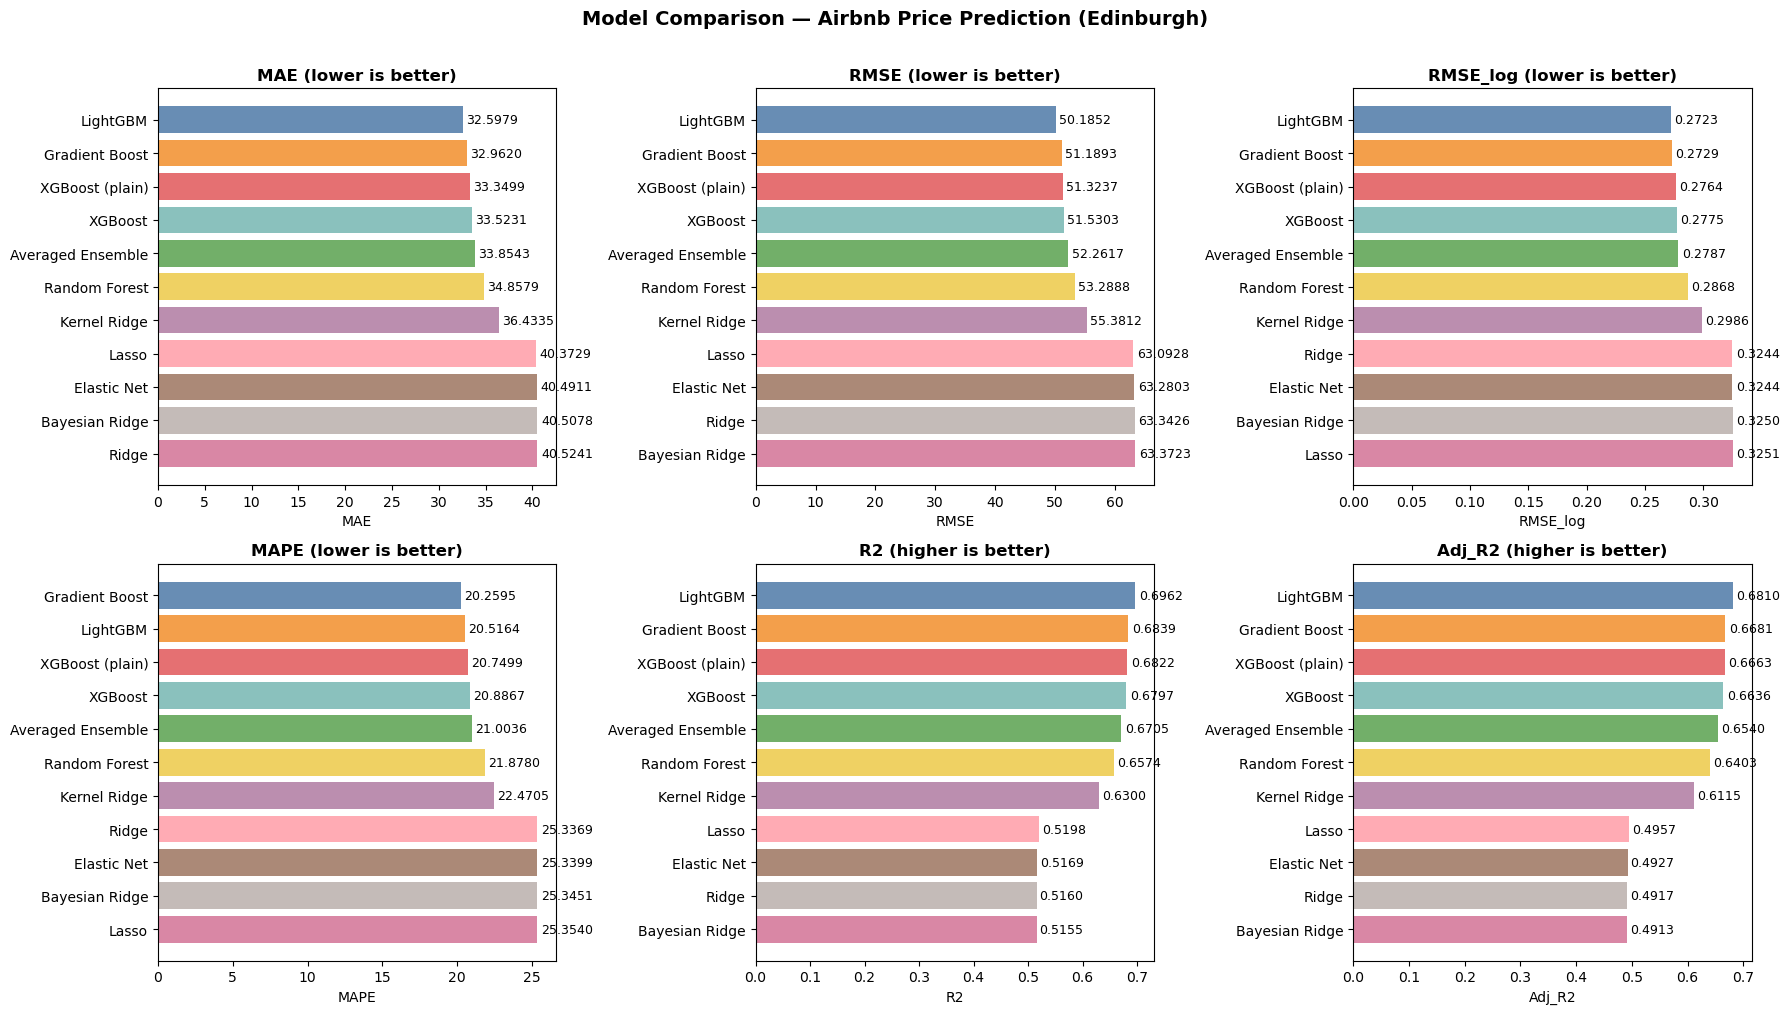

  model_comparison.png saved


In [ ]:

RUN_LABEL = "qwen_combined_POI1500m"    # change per run: "qwen_800m", "nemo_500m", etc.

PALETTE = ["#4E79A7", "#F28E2B", "#E15759", "#76B7B2",
           "#59A14F", "#EDC948", "#B07AA1", "#FF9DA7", "#9C755F", "#BAB0AC", "#D37295"]

metrics_plot = ["MAE", "RMSE", "RMSE_log", "MAPE", "R2", "Adj_R2"]
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for ax, metric in zip(axes.flatten(), metrics_plot):
    higher_better = metric in ("R2", "Adj_R2")
    data_sorted   = results_df.sort_values(metric, ascending=not higher_better)
    bars = ax.barh(data_sorted["Model"], data_sorted[metric],
                   color=PALETTE[:len(data_sorted)], alpha=0.85)
    ax.set_xlabel(metric)
    direction = "higher is better" if higher_better else "lower is better"
    ax.set_title(f"{metric} ({direction})", fontweight="bold")
    ax.invert_yaxis()
    for bar, val in zip(bars, data_sorted[metric]):
        ax.text(bar.get_width() * 1.01, bar.get_y() + bar.get_height() / 2,
                f"{val:.4f}", va="center", fontsize=9)

plt.suptitle("Model Comparison — Airbnb Price Prediction (Edinburgh)",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(f"model_comparison_{RUN_LABEL}.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close()
print("  model_comparison.png saved")


## Plot 2 — All-model predictions vs actuals 

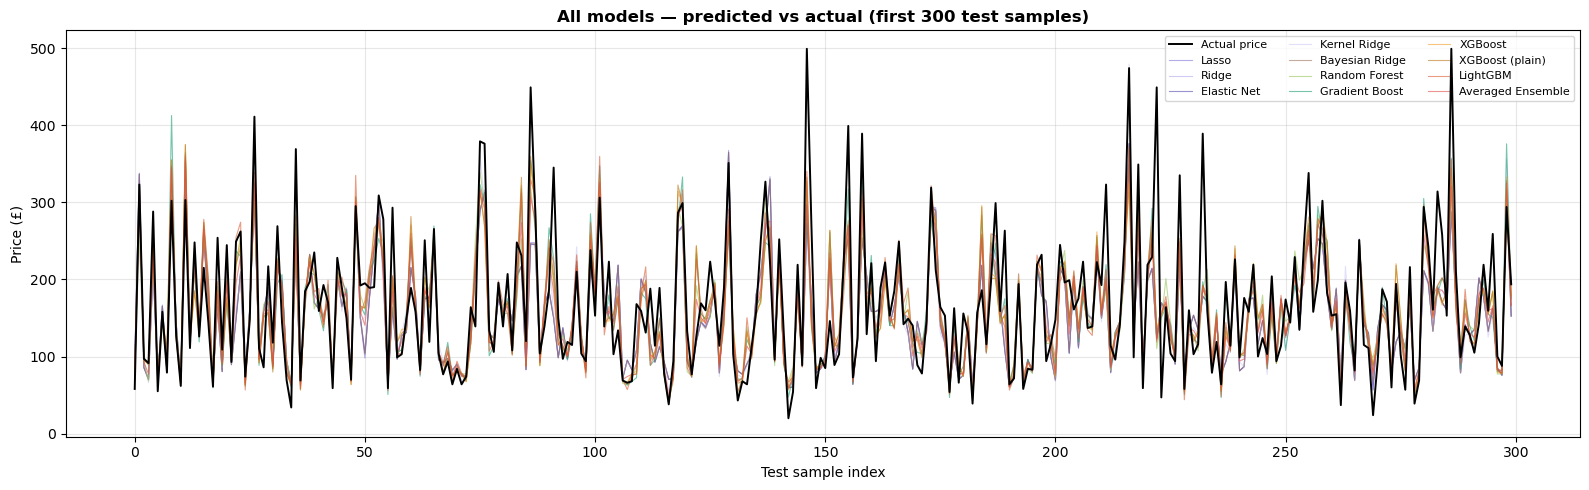

  predictions_vs_actual.png saved


In [ ]:
y_test_orig = np.expm1(y_test.values)
n_plot      = min(300, len(y_test))
idx         = range(n_plot)

PRED_COLORS = {
    "Lasso":             "#7F77DD",
    "Ridge":             "#AFA9EC",
    "Elastic Net":       "#534AB7",
    "Kernel Ridge":      "#CECBF6",
    "Bayesian Ridge":    "#9C755F",
    "Random Forest":     "#97C459",
    "Gradient Boost":    "#1D9E75",
    "XGBoost":           "#EF9F27",
    "XGBoost (plain)":   "#BA7517",
    "LightGBM":          "#D85A30",
    "Averaged Ensemble": "#E24B4A",
}

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(idx, y_test_orig[:n_plot], "k-", lw=1.4, label="Actual price", zorder=10)

for name, y_pred_log in all_preds.items():
    y_pred = np.expm1(y_pred_log)
    ax.plot(idx, y_pred[:n_plot],
            linewidth=0.8, alpha=0.6,
            color=PRED_COLORS.get(name, "#888"), label=name)

ax.set_xlabel("Test sample index")
ax.set_ylabel("Price (£)")
ax.set_title("All models — predicted vs actual (first 300 test samples)", fontweight="bold")
ax.legend(fontsize=8, ncol=3, loc="upper right")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"predictions_vs_actual_{RUN_LABEL}.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close()
print("  predictions_vs_actual.png saved")


## Plot 3 — Best model only (clean view)

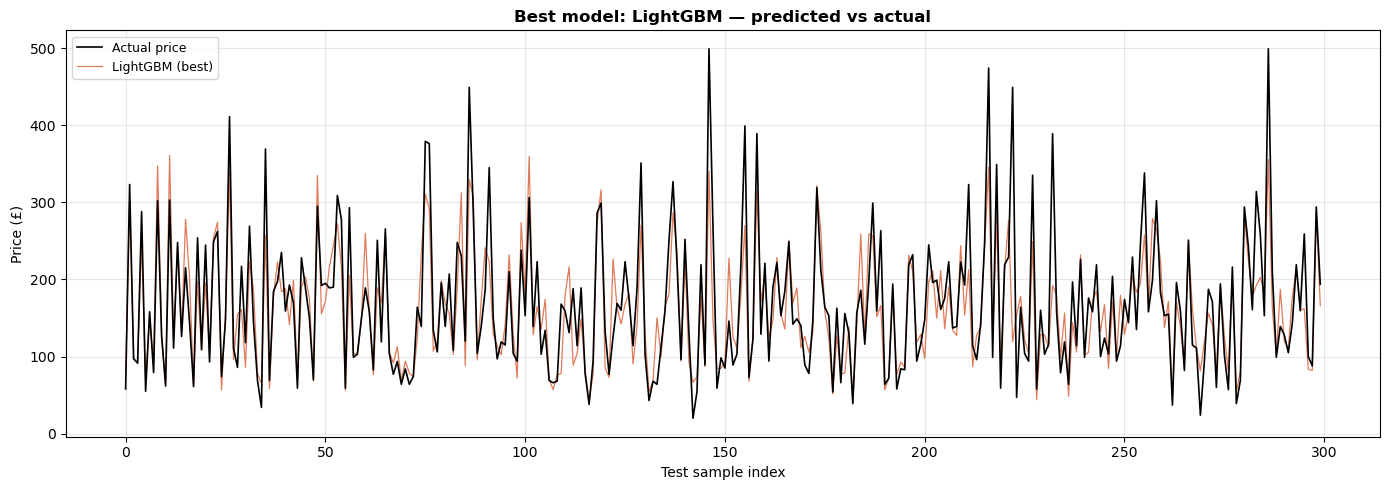

  predictions_best_model.png saved


In [ ]:
best_name  = results_df.iloc[0]["Model"]
y_best_log = all_preds[best_name]
y_best     = np.expm1(y_best_log)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(idx, y_test_orig[:n_plot], "k-", lw=1.2, label="Actual price", zorder=5)
ax.plot(idx, y_best[:n_plot], "-", lw=0.9, alpha=0.8,
        color=PRED_COLORS.get(best_name, "#E15759"), label=f"{best_name} (best)")
ax.set_xlabel("Test sample index")
ax.set_ylabel("Price (£)")
ax.set_title(f"Best model: {best_name} — predicted vs actual", fontweight="bold")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"predictions_best_model_{RUN_LABEL}.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close()
print("  predictions_best_model.png saved")

## Plot 4a — Feature importance (RF, coloured by core IV vs control)

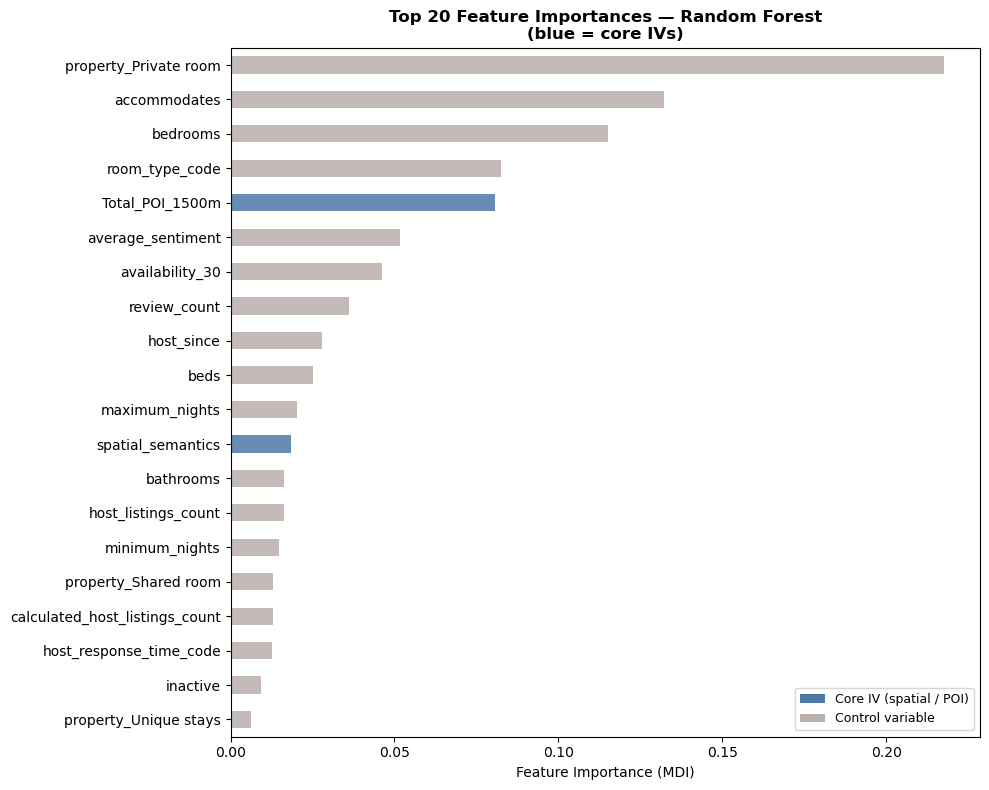

  feature_importance.png saved

  Top 20 feature importances (Random Forest):
property_Private room             0.217733
accommodates                      0.132290
bedrooms                          0.115202
room_type_code                    0.082488
Total_POI_1500m                   0.080759
average_sentiment                 0.051633
availability_30                   0.046321
review_count                      0.036169
host_since                        0.028012
beds                              0.025286
maximum_nights                    0.020213
spatial_semantics                 0.018332
bathrooms                         0.016381
host_listings_count               0.016164
minimum_nights                    0.014738
property_Shared room              0.012892
calculated_host_listings_count    0.012830
host_response_time_code           0.012514
inactive                          0.009183
property_Unique stays             0.006345


In [ ]:
# Always derive feature names from what RF actually saw during training
importances = pd.Series(
    rf.feature_importances_,
    index=X_train.columns   # guaranteed to match length
)
top20 = importances.nlargest(20).sort_values()

fig, ax = plt.subplots(figsize=(10, 8))
colors = ["#4E79A7" if f in CORE_IVS else "#BAB0AC" for f in top20.index]
top20.plot(kind="barh", ax=ax, color=colors, alpha=0.85)

legend_elements = [
    mpatches.Patch(facecolor="#4E79A7", label="Core IV (spatial / POI)"),
    mpatches.Patch(facecolor="#BAB0AC", label="Control variable"),
]
ax.legend(handles=legend_elements, loc="lower right", fontsize=9)
ax.set_xlabel("Feature Importance (MDI)")
ax.set_title("Top 20 Feature Importances — Random Forest\n(blue = core IVs)",
             fontweight="bold")
plt.tight_layout()
plt.savefig(f"feature_importance_{RUN_LABEL}.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close()
print("  feature_importance.png saved")

print("\n  Top 20 feature importances (Random Forest):")
print(top20.sort_values(ascending=False).to_string())

The Random Forest feature importance chart reveals a clear hierarchy in Edinburgh Airbnb pricing. Structural listing characteristics dominate the top positions: `property_Private room` (0.240) ranks first by a wide margin, followed by `accommodates` (0.129), `bedrooms` (0.114), and `room_type_code` (0.108). The large importance of `property_Private room` reflects the substantial price discount associated with partial-property listings relative to entire homes.

Among the core independent variables, `Total_POI_800m` ranks 5th overall (0.073), placing it ahead of all host, policy, and amenity controls and immediately behind the four structural features. This confirms that the density of nearby points of interest within 800 metres is a meaningful price determinant in the Edinburgh market. `spatial_semantics` ranks 14th (0.012), a modest but non-zero contribution that places it alongside host operational variables such as `host_listings_count` and `calculated_host_listings_count`.

`average_sentiment` (0.057) and `review_count` (0.043) both outperform `availability_30` (0.039) and all amenity-related features, suggesting that the reputational signal from guest reviews carries more pricing information than booking policy or physical amenities in this market. Features below `host_since` collectively contribute less than 0.02 each, indicating a long tail of weak individual predictors.

## Top 20 feature importance based on the best perfroming model -here LightGBM

In [1]:
# LightGBM feature importances (gain-based, more reliable than split count)
importances = pd.Series(
    model_lgb.feature_importances_,
    index=X_train.columns
)
top20 = importances.nlargest(20).sort_values()

fig, ax = plt.subplots(figsize=(10, 8))
colors = ["#4E79A7" if f in CORE_IVS else "#BAB0AC" for f in top20.index]
top20.plot(kind="barh", ax=ax, color=colors, alpha=0.85)

legend_elements = [
    mpatches.Patch(facecolor="#4E79A7", label="Core IV (spatial / POI)"),
    mpatches.Patch(facecolor="#BAB0AC", label="Control variable"),
]
ax.legend(handles=legend_elements, loc="lower right", fontsize=9)
ax.set_xlabel("Feature Importance (split count)")
ax.set_title("Top 20 Feature Importances — LightGBM\n(blue = core IVs)",
             fontweight="bold")
plt.tight_layout()
plt.savefig(f"feature_importance_{RUN_LABEL}.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close()
print("  feature_importance.png saved")

print("\n  Top 20 feature importances (LightGBM):")
print(top20.sort_values(ascending=False).to_string())

<text>:6:33: unexpected symbol
5: )
6: top20 = importances.nlargest(20).sort_values
                                   ^

## Save results CSV

In [ ]:
results_df.to_csv(f"model_results_{RUN_LABEL}.csv", index=False)
print(f"\n  model_results_{RUN_LABEL}.csv saved")


  model_results_qwen_combined_POI1500m.csv saved


# Final summary


In [ ]:
print(f"\n{'='*65}")
print(f"  Best model   : {best_name}")
print(f"  Test RMSE_log: {results_df.iloc[0]['RMSE_log']:.4f}")
print(f"  Test R²      : {results_df.iloc[0]['R2']:.4f}")
print(f"  Test R²_log  : {results_df.iloc[0]['R2_log']:.4f}")
print(f"{'='*65}")
print("\nOutputs saved:")
print("  model_comparison.png")
print("  predictions_vs_actual.png   (all models)")
print("  predictions_best_model.png  (best model only)")
print("  feature_importance.png      (RF, core IVs highlighted)")
print("  model_results.csv")


  Best model   : LightGBM
  Test RMSE_log: 0.2723
  Test R²      : 0.6962
  Test R²_log  : 0.7514

Outputs saved:
  model_comparison.png
  predictions_vs_actual.png   (all models)
  predictions_best_model.png  (best model only)
  feature_importance.png      (RF, core IVs highlighted)
  model_results.csv


In [ ]:
# Check 1 — how important is professional_host in each model?
importances_lgb = pd.Series(
    model_lgb.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print("LightGBM top 10 features:")
print(importances_lgb.head(10))

# Check 2 — is professional_host correlated with existing columns?
corr = X_train[["professional_host",
                "host_listings_count",
                "calculated_host_listings_count"]].corr()
print("\nCorrelation matrix:")
print(corr)

# Check 3 — price difference between professional and non-professional
prof_price     = np.expm1(y_train[X_train["professional_host"] == 1]).mean()
nonprof_price  = np.expm1(y_train[X_train["professional_host"] == 0]).mean()
print(f"\nMean price — professional hosts    : £{prof_price:.2f}")
print(f"Mean price — non-professional hosts: £{nonprof_price:.2f}")
print(f"Price premium / discount           : £{prof_price - nonprof_price:.2f}")

LightGBM top 10 features:
Total_POI_1500m                   4953
host_since                        4209
average_sentiment                 3852
review_count                      3622
availability_30                   3053
spatial_semantics                 2333
maximum_nights                    2232
host_listings_count               1676
minimum_nights                    1384
calculated_host_listings_count    1308
dtype: int32

Correlation matrix:
                                professional_host  host_listings_count  \
professional_host                        1.000000             0.164463   
host_listings_count                      0.164463             1.000000   
calculated_host_listings_count           0.408406             0.202281   

                                calculated_host_listings_count  
professional_host                                     0.408406  
host_listings_count                                   0.202281  
calculated_host_listings_count                        1.00

## Explanations of Checks 
If Check 1 shows professional_host ranks high in LightGBM importance but low in RF importance, it confirms LightGBM is exploiting it more aggressively. If Check 2 shows correlation above 0.8 with the count columns, it confirms redundancy is part of the story. If Check 3 shows a meaningful price difference, it confirms the variable carries genuine economic signal worth including in our paper.

| | `model_xgb` | `model_xgb_plain` |
|---|---|---|
| Hyperparameters | best from Hyperopt | identical |
| Early stopping | yes (rounds=20) | no |
| Needs `eval_set` | yes — crashes without it | no |
| Used for | standalone test evaluation | ensemble + CV |
| Trees built | may be fewer (stopped early) | always `n_estimators` trees |

## Residual analysis


In [ ]:
import os
os.makedirs("figures", exist_ok=True)

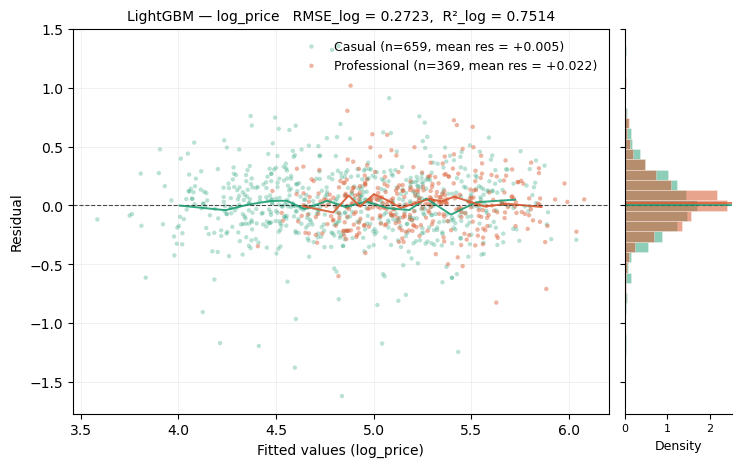

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec


def plot_lgbm_residuals_by_host_type(
    model,
    X_test,
    y_test,
    is_professional,
    target_name="log_price",
    figsize=(8.5, 5),
    save_path=None,
):
    """
    Residuals vs. fitted plot for the best-performing LightGBM model,
    with points coloured by host type (professional vs casual) and a
    marginal histogram of residuals on the right edge.

    Parameters
    ----------
    model : fitted LightGBM regressor
    X_test : test feature matrix (DataFrame or array)
    y_test : true test targets on the log scale
    is_professional : 1-D array-like of 0/1 or bool, same length as y_test
    target_name : str, used in axis labels and title
    figsize : tuple, figure size
    save_path : str or None, if provided saves the figure at 300 dpi

    Returns
    -------
    fig : matplotlib Figure
    """
    # Colour scheme: professional = coral, casual = teal
    colour_pro = "#D85A30"
    colour_cas = "#1D9E75"

    # Compute residuals and grouping
    y_true = np.asarray(y_test)
    y_pred = model.predict(X_test)
    residuals = y_true - y_pred
    is_pro = np.asarray(is_professional).astype(bool)

    # Performance summary on the log scale
    rmse_log = np.sqrt(np.mean(residuals ** 2))
    r2_log = 1 - np.sum(residuals ** 2) / np.sum((y_true - y_true.mean()) ** 2)

    # Group-level mean residual (quick bias check)
    mean_res_pro = residuals[is_pro].mean()
    mean_res_cas = residuals[~is_pro].mean()
    n_pro = int(is_pro.sum())
    n_cas = int((~is_pro).sum())

    # --- Layout: scatter + marginal histogram ---
    fig = plt.figure(figsize=figsize)
    gs = GridSpec(1, 2, width_ratios=[5, 1], wspace=0.05, figure=fig)

    # --- Main scatter ---
    ax_main = fig.add_subplot(gs[0, 0])

    # Casual plotted first so the smaller professional group sits on top
    ax_main.scatter(
        y_pred[~is_pro], residuals[~is_pro],
        s=10, alpha=0.30,
        color=colour_cas, edgecolor="none",
        label=f"Casual (n={n_cas}, mean res = {mean_res_cas:+.3f})",
    )
    ax_main.scatter(
        y_pred[is_pro], residuals[is_pro],
        s=10, alpha=0.45,
        color=colour_pro, edgecolor="none",
        label=f"Professional (n={n_pro}, mean res = {mean_res_pro:+.3f})",
    )

    ax_main.axhline(0, color="black", linewidth=0.8, linestyle="--", alpha=0.7)

    # Per-group binned-mean trend lines
    for mask, colour in [(~is_pro, colour_cas), (is_pro, colour_pro)]:
        if mask.sum() < 40:
            continue
        yp = y_pred[mask]
        res = residuals[mask]
        order = np.argsort(yp)
        idx_bins = np.array_split(order, 15)
        bin_x = [yp[b].mean() for b in idx_bins if len(b) > 0]
        bin_y = [res[b].mean() for b in idx_bins if len(b) > 0]
        ax_main.plot(bin_x, bin_y, color=colour, linewidth=1.4, alpha=0.9)

    ax_main.set_xlabel(f"Fitted values ({target_name})")
    ax_main.set_ylabel("Residual")
    ax_main.set_title(
        f"LightGBM — {target_name}   RMSE_log = {rmse_log:.4f},  R²_log = {r2_log:.4f}",
        fontsize=10,
    )
    ax_main.legend(frameon=False, fontsize=9, loc="upper right")
    ax_main.grid(True, alpha=0.25, linewidth=0.5)

    # --- Marginal histogram ---
    ax_marg = fig.add_subplot(gs[0, 1], sharey=ax_main)

    bin_edges = np.linspace(residuals.min(), residuals.max(), 35)

    ax_marg.hist(
        residuals[~is_pro], bins=bin_edges, orientation="horizontal",
        color=colour_cas, alpha=0.50,
        edgecolor="white", linewidth=0.4, density=True,
    )
    ax_marg.hist(
        residuals[is_pro], bins=bin_edges, orientation="horizontal",
        color=colour_pro, alpha=0.55,
        edgecolor="white", linewidth=0.4, density=True,
    )

    ax_marg.axhline(0, color="black", linewidth=0.8, linestyle="--", alpha=0.7)
    ax_marg.axhline(mean_res_cas, color=colour_cas, linewidth=1.2, alpha=0.9)
    ax_marg.axhline(mean_res_pro, color=colour_pro, linewidth=1.2, alpha=0.9)

    plt.setp(ax_marg.get_yticklabels(), visible=False)
    ax_marg.set_xlabel("Density", fontsize=9)
    ax_marg.tick_params(axis="x", labelsize=8)
    ax_marg.spines["top"].set_visible(False)
    ax_marg.spines["right"].set_visible(False)

    plt.tight_layout()

    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches="tight")

    return fig


# --------- Usage ---------
# Pull the professional flag from the test set BEFORE it gets dropped
# (it's still a column in X_test in your pipeline)
is_pro_test = X_test["professional_host"].values

fig = plot_lgbm_residuals_by_host_type(
    model=model_lgb,
    X_test=X_test,
    y_test=y_test,
    is_professional=is_pro_test,
    target_name="log_price",
    save_path="figures/residuals_lgbm_logprice.png",
)
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec


def plot_lgbm_residuals_by_host_type(
    model,
    X_test,
    y_test,
    is_professional,
    target_name="log_price",
    figsize=(8.5, 5),
    save_path=None,
):
    """
    Residuals vs. fitted plot for a LightGBM regressor on log_price,
    with points coloured by host type (professional vs casual) and a
    marginal histogram of residuals on the right edge.

    Parameters
    ----------
    model : fitted LightGBM regressor (e.g. lightgbm.LGBMRegressor)
    X_test : test feature matrix (DataFrame or array)
    y_test : true test targets on the log scale
    is_professional : 1-D array-like of 0/1 or bool, same length as y_test,
                      marking professional hosts (1/True) and casual hosts (0/False)
    target_name : str, used in axis labels and title
    figsize : tuple, figure size
    save_path : str or None, if provided saves the figure at 300 dpi

    Returns
    -------
    fig : matplotlib Figure
    """
    # Colour scheme: professional = coral, casual = teal
    # Colour-blind safe and prints legibly in greyscale
    colour_pro = "#D85A30"
    colour_cas = "#1D9E75"

    # Compute residuals and grouping
    y_true = np.asarray(y_test)
    y_pred = model.predict(X_test)
    residuals = y_true - y_pred
    is_pro = np.asarray(is_professional).astype(bool)

    # Performance summary
    rmse = np.sqrt(np.mean(residuals ** 2))
    r2 = 1 - np.sum(residuals ** 2) / np.sum((y_true - y_true.mean()) ** 2)

    # Group-level mean residual (quick bias check)
    mean_res_pro = residuals[is_pro].mean()
    mean_res_cas = residuals[~is_pro].mean()
    n_pro = is_pro.sum()
    n_cas = (~is_pro).sum()

    # --- Layout: scatter + marginal histogram ---
    fig = plt.figure(figsize=figsize)
    gs = GridSpec(1, 2, width_ratios=[5, 1], wspace=0.05, figure=fig)

    # --- Main scatter ---
    ax_main = fig.add_subplot(gs[0, 0])

    # Casual plotted first so the smaller professional group sits on top
    ax_main.scatter(
        y_pred[~is_pro], residuals[~is_pro],
        s=10, alpha=0.30,
        color=colour_cas, edgecolor="none",
        label=f"Casual (n={n_cas}, mean res = {mean_res_cas:+.3f})",
    )
    ax_main.scatter(
        y_pred[is_pro], residuals[is_pro],
        s=10, alpha=0.45,
        color=colour_pro, edgecolor="none",
        label=f"Professional (n={n_pro}, mean res = {mean_res_pro:+.3f})",
    )

    ax_main.axhline(0, color="black", linewidth=0.8, linestyle="--", alpha=0.7)

    # Per-group binned-mean trend lines
    for mask, colour in [(~is_pro, colour_cas), (is_pro, colour_pro)]:
        if mask.sum() < 40:
            continue
        yp = y_pred[mask]
        res = residuals[mask]
        order = np.argsort(yp)
        idx_bins = np.array_split(order, 15)
        bin_x = [yp[b].mean() for b in idx_bins if len(b) > 0]
        bin_y = [res[b].mean() for b in idx_bins if len(b) > 0]
        ax_main.plot(bin_x, bin_y, color=colour, linewidth=1.4, alpha=0.9)

    ax_main.set_xlabel(f"Fitted values ({target_name})")
    ax_main.set_ylabel("Residual")
    ax_main.set_title(
        f"LightGBM — {target_name}   RMSE = {rmse:.4f},  R² = {r2:.4f}",
        fontsize=10,
    )
    ax_main.legend(frameon=False, fontsize=9, loc="upper right")
    ax_main.grid(True, alpha=0.25, linewidth=0.5)

    # --- Marginal histogram ---
    ax_marg = fig.add_subplot(gs[0, 1], sharey=ax_main)

    # Shared bin edges so the two distributions are directly comparable
    bin_edges = np.linspace(residuals.min(), residuals.max(), 35)

    ax_marg.hist(
        residuals[~is_pro], bins=bin_edges, orientation="horizontal",
        color=colour_cas, alpha=0.50,
        edgecolor="white", linewidth=0.4, density=True,
    )
    ax_marg.hist(
        residuals[is_pro], bins=bin_edges, orientation="horizontal",
        color=colour_pro, alpha=0.55,
        edgecolor="white", linewidth=0.4, density=True,
    )

    ax_marg.axhline(0, color="black", linewidth=0.8, linestyle="--", alpha=0.7)
    # Group-mean residual lines on the marginal
    ax_marg.axhline(mean_res_cas, color=colour_cas, linewidth=1.2, alpha=0.9)
    ax_marg.axhline(mean_res_pro, color=colour_pro, linewidth=1.2, alpha=0.9)

    plt.setp(ax_marg.get_yticklabels(), visible=False)
    ax_marg.set_xlabel("Density", fontsize=9)
    ax_marg.tick_params(axis="x", labelsize=8)
    ax_marg.spines["top"].set_visible(False)
    ax_marg.spines["right"].set_visible(False)

    plt.tight_layout()

    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches="tight")

    return fig


# --------- Usage ---------
# Assumes you have a fitted LightGBM model and an aligned professional flag.

fig = plot_lgbm_residuals_by_host_type(
    model=lgbm_model_price,
    X_test=X_test_price,
    y_test=y_test_price,
    is_professional=is_pro_test_price,
    target_name="log_price",
    save_path="figures/residuals_lgbm_logprice.png",
)
plt.show()

NameError: name 'lgbm_model_price' is not defined

## SHAP Analysis

In [ ]:
pip install shap

In [ ]:
# Compute SHAP values for the best model
import shap
 
EXPLAIN_NAME = "LightGBM"
explain_model = MODEL_DICT[EXPLAIN_NAME]
 
# Subsample test set for speed — 500 is more than enough for stable global plots
N_SHAP = min(500, len(X_test))
X_shap = X_test.sample(N_SHAP, random_state=42).reset_index(drop=True)
 
# TreeExplainer gives exact Shapley values for tree-based models
explainer   = shap.TreeExplainer(explain_model)
shap_values = explainer.shap_values(X_shap)
 
base_val = float(np.ravel(explainer.expected_value)[0])
 
# Build ONE Explanation object — reused for every plot
explanation = shap.Explanation(
    values        = shap_values,
    base_values   = np.full(shap_values.shape[0], base_val),  # expand scalar to array
    data          = X_shap.values,
    feature_names = X_shap.columns.tolist(),
)
 
print(f"    SHAP values computed for {EXPLAIN_NAME}")
print(f"    Samples explained : {N_SHAP}")
print(f"    Shape             : {shap_values.shape}")
print(f"    Base value E[f(x)]: {base_val:.4f}  (log-price space)")



In [ ]:
# Get the top 20 features by mean absolute SHAP value
feature_names = X_shap.columns.tolist()
mean_abs_shap = np.abs(shap_values).mean(axis=0)
top20_shap = pd.Series(mean_abs_shap, index=feature_names).nlargest(20).sort_values()

# Build colours — blue for core IVs, grey for everything else
colors = ["#4E79A7" if f in CORE_IVS else "#BAB0AC" for f in top20_shap.index]

# Draw the bar chart manually so we control colours
fig, ax = plt.subplots(figsize=(10, 8))
bars = top20_shap.plot(kind="barh", ax=ax, color=colors, alpha=0.85)

# Add value labels at the end of each bar
for bar, val in zip(ax.patches, top20_shap.values):
    ax.text(
        bar.get_width() + 0.0005,          # x position: just past the bar end
        bar.get_y() + bar.get_height() / 2, # y position: vertically centred
        f"+{val:.4f}",                      # label: +0.0123
        va="center",
        ha="left",
        fontsize=8,
        color="#444444",
    )

# Give right margin room for the labels
ax.set_xlim(0, top20_shap.max() * 1.25)

# Legend
legend_elements = [
    mpatches.Patch(facecolor="#4E79A7", label="Core IV (spatial / POI)"),
    mpatches.Patch(facecolor="#BAB0AC", label="Control variable"),
]
ax.legend(handles=legend_elements, loc="lower right", fontsize=9)

ax.set_xlabel("Mean |SHAP value|")
ax.set_title(f"SHAP Feature Importance — {EXPLAIN_NAME}", fontweight="bold")
plt.tight_layout()
plt.savefig("shap_bar.png", dpi=200, bbox_inches="tight")
plt.show()
plt.close()
print("  shap_bar.png saved")

In [ ]:
# Global feature importance plot
shap.plots.bar(explanation, max_display=20, show=False)
plt.title(f"SHAP Feature Importance — {EXPLAIN_NAME}", fontweight="bold")
plt.tight_layout()
plt.savefig("shap_bar.png", dpi=200, bbox_inches="tight")
plt.show()
plt.close()
print("  shap_bar.png saved")

The SHAP bar plot ranks features by their mean absolute contribution to price prediction. The top three features are structural listing characteristics: `accommodates` (0.12), `Total_POI_800m` (0.10), and `bedrooms` (0.10), confirming the model captures economically rational pricing fundamentals.

Among the two core independent variables, `Total_POI_800m` ranks 2nd overall (0.10), placing it immediately behind `accommodates` and ahead of all host, policy, and amenity controls. This confirms that objective spatial context within 800m walking distance is a substantial price driver in the Edinburgh Airbnb market. `spatial_semantics` ranks 15th (0.02), contributing at a level comparable to `professional_host`, `host_listings_count`, and `host_is_superhost`. While modest, it is not negligible and indicates that LLM-extracted spatial references carry incremental predictive information beyond what raw POI counts capture.

The gap between `Total_POI_800m` (0.10) and `spatial_semantics` (0.02) suggests that what is objectively nearby matters considerably more than how hosts describe their surroundings. However, `spatial_semantics` may capture information absent from the POI dataset, such as references to named neighbourhoods, transport links, or landmarks not represented in the POI buffer.

Notably, `average_sentiment` (0.08) and `review_count` (0.06) rank 4th and 6th, outperforming most host and amenity variables, indicating that reputation signals play a meaningful role in price determination. `property_Private room` (0.07) and `room_type_code` (0.05) further confirm that listing type remains a key structural determinant of price.

In [ ]:
pip install plotly

In [ ]:
import plotly.graph_objects as go
import plotly.io as pio
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors

# Build top 20 feature summary 
feature_names = X_shap.columns.tolist()

mean_abs_shap = np.abs(shap_values).mean(axis=0)
shap_summary  = pd.DataFrame({
    "feature":     feature_names,
    "mean_abs":    mean_abs_shap,
    "mean_signed": shap_values.mean(axis=0),
    "std":         np.abs(shap_values).std(axis=0),
}).sort_values("mean_abs", ascending=False).head(20)

top20_features = shap_summary["feature"].tolist()
top20_idx      = [feature_names.index(f) for f in top20_features]

# Build dot data
rows = []
for rank, (feat, idx) in enumerate(zip(top20_features, top20_idx)):
    shap_vals  = shap_values[:, idx]
    feat_vals  = X_shap.iloc[:, idx].values
    fmin, fmax = feat_vals.min(), feat_vals.max()
    feat_norm  = (feat_vals - fmin) / (fmax - fmin + 1e-9)
    for sv, fv, fn in zip(shap_vals, feat_vals, feat_norm):
        rows.append({
            "feature":   feat,
            "rank":      rank,
            "shap":      sv,
            "feat_val":  fv,
            "feat_norm": fn,
        })

df_plot = pd.DataFrame(rows)

rng = np.random.default_rng(42)
df_plot["y_jitter"] = df_plot["rank"] + rng.uniform(-0.35, 0.35, len(df_plot))

# Interactive plotly figure 
fig = go.Figure()

fig.add_trace(go.Scatter(
    x    = df_plot["shap"],
    y    = df_plot["y_jitter"],
    mode = "markers",
    marker = dict(
        size       = 4,
        color      = df_plot["feat_norm"],
        colorscale = "RdBu_r",
        cmin       = 0,
        cmax       = 1,
        colorbar   = dict(
            title     = "Feature value",
            tickvals  = [0, 0.5, 1],
            ticktext  = ["Low", "Mid", "High"],
            thickness = 12,
            len       = 0.6,
        ),
        opacity = 0.7,
        line    = dict(width=0),
    ),
    customdata = np.stack([
        df_plot["feature"],
        df_plot["feat_val"].round(3),
        df_plot["shap"].round(4),
    ], axis=1),
    hovertemplate = (
        "<b>%{customdata[0]}</b><br>"
        "Feature value : %{customdata[1]}<br>"
        "SHAP value    : %{customdata[2]}<br>"
        "<extra></extra>"
    ),
))

fig.add_vline(x=0, line_width=1, line_dash="dot", line_color="grey")

fig.update_layout(
    title = dict(
        text      = f"Interactive SHAP beeswarm — {EXPLAIN_NAME} (top 20 features)",
        font_size = 15,
        x         = 0.5,
    ),
    xaxis = dict(
        title     = "SHAP value (impact on model output)",
        zeroline  = False,
        gridcolor = "rgba(200,200,200,0.3)",
    ),
    yaxis = dict(
        tickmode  = "array",
        tickvals  = list(range(20)),
        ticktext  = top20_features,
        autorange = "reversed",
        gridcolor = "rgba(200,200,200,0.3)",
    ),
    plot_bgcolor  = "white",
    paper_bgcolor = "white",
    height        = 700,
    width         = 900,
    margin        = dict(l=220, r=80, t=60, b=60),
    showlegend    = False,
)

fig.show()

# Save interactive HTML — works always, no kaleido needed
fig.write_html("shap_interactive_beeswarm.html")
print("  shap_interactive_beeswarm.html saved")

# Save static PNG via matplotlib — no kaleido needed
fig_mpl, ax = plt.subplots(figsize=(10, 8))

for rank, feat in enumerate(top20_features):
    idx        = feature_names.index(feat)
    shap_vals  = shap_values[:, idx]
    feat_vals  = X_shap.iloc[:, idx].values
    fmin, fmax = feat_vals.min(), feat_vals.max()
    feat_norm  = (feat_vals - fmin) / (fmax - fmin + 1e-9)
    jitter     = np.random.default_rng(rank).uniform(-0.35, 0.35, len(shap_vals))
    ax.scatter(shap_vals, rank + jitter,
               c=cm.RdBu_r(feat_norm), s=8, alpha=0.6, linewidths=0)

ax.axvline(0, color="grey", linewidth=0.8, linestyle="--")
ax.set_yticks(range(20))
ax.set_yticklabels(top20_features, fontsize=9)
ax.invert_yaxis()
ax.set_xlabel("SHAP value (impact on model output)")
ax.set_title(f"SHAP beeswarm — {EXPLAIN_NAME} (top 20 features)", fontweight="bold")

sm = plt.cm.ScalarMappable(cmap="RdBu_r", norm=mcolors.Normalize(0, 1))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, shrink=0.5)
cbar.set_label("Feature value")
cbar.set_ticks([0, 0.5, 1])
cbar.set_ticklabels(["Low", "Mid", "High"])

plt.tight_layout()
plt.savefig("shap_interactive_beeswarm.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close()
print("  shap_interactive_beeswarm.png saved")

The beeswarm plot confirms the feature importance hierarchy from the bar chart, while adding directional and distributional information. Each dot is one listing, positioned horizontally by its SHAP contribution to predicted log-price, with colour encoding the raw feature value (red = high, blue = low).

`accommodates`, `bedrooms`, and `Total_POI_800m` dominate the top three positions with the widest horizontal spread, reaching SHAP values beyond ±0.4. For `accommodates` and `bedrooms` the pattern is intuitive: red dots (larger listings) push prices up while blue dots (smaller) pull them down. `Total_POI_800m` shows a similar directional pattern, with high-POI listings (red) consistently receiving positive contributions and low-POI listings (blue) receiving negative ones, confirming a monotonic location premium.

`average_sentiment` ranks 4th and shows a clear positive relationship, higher sentiment scores are associated with upward price contributions, suggesting that guest satisfaction carries genuine pricing signal beyond structural characteristics.

`property_Private room` shows a distinctive bimodal pattern: high values (red, meaning the listing is a private room) cluster on the left, confirming the well-documented price discount for partial-property listings. `room_type_code` shows a similar but less pronounced pattern.

`spatial_semantics` sits 14th, with a narrow distribution tightly clustered around zero. There is a slight rightward lean for higher values but the effect is small and heterogeneous, consistent with its modest mean |SHAP| of 0.02. Features below `host_listings_count`, including `amenity_tv`, `minimum_nights`, and `instant_bookable`, all show very tight distributions near zero, confirming they contribute little marginal pricing information once the dominant structural and spatial features are accounted for.

In [ ]:
# Beeswarm plot
shap.plots.beeswarm(explanation, max_display=20, show=False)
plt.title(f"SHAP Beeswarm — {EXPLAIN_NAME}", fontweight="bold")
plt.tight_layout()
plt.savefig("shap_beeswarm.png", dpi=200, bbox_inches="tight")
plt.show()
plt.close()
print("  shap_beeswarm.png saved")

The beeswarm plot reveals the direction and heterogeneity of each feature's impact on predicted log-price. Each dot represents one listing; colour encodes the feature's raw value (red = high, blue = low), and horizontal position indicates the SHAP contribution (right = pushes price up, left = pushes price down).

The structural features display clear, expected patterns: `bedrooms` and `accommodates` show red dots concentrated on the right and blue dots on the left, confirming that larger listings command higher prices. `property_Private room` shows the reverse — high values consistently push predictions downward, reflecting the well-documented price discount for partial-property listings.

For the core independent variables, `Total_POI_800m` shows a positive directional trend: red dots (higher POI density) tend to fall on the right side, while blue dots (lower density) cluster on the left. This confirms that proximity to points of interest within 800m has a monotonically positive association with predicted price, consistent with location theory. The spread of dots for `Total_POI_800m` is notably wide, extending to SHAP values of approximately +0.4, indicating that high-density locations can substantially boost predicted prices. `spatial_semantics` (ranked 15th) shows a slight rightward lean for red dots, indicating that richer spatial descriptions are associated with marginally higher predicted prices, though the effect is small and dispersed compared to `Total_POI_800m`. The distribution for `spatial_semantics` is tightly clustered near zero, consistent with its modest mean absolute SHAP value of 0.02.

`average_sentiment` exhibits a clear positive pattern: higher sentiment scores push prices up, while `review_count` shows a more concentrated distribution near zero with occasional negative outliers, suggesting that very high review counts may signal budget-oriented listings. `room_type_code` displays a few extreme negative outliers, reflecting the categorical price penalty for non-entire-home listings.

`professional_host` shows a predominantly blue cluster near zero with a small rightward spread for high values, suggesting a modest positive premium for professional operators but with considerable heterogeneity across listings. `host_is_superhost` similarly shows a slight positive lean for high values, though the effect is marginal.

Several features including `host_since`, `maximum_nights`, `calculated_host_listings_count`, and `gender_final` show symmetric, tightly clustered distributions around zero, indicating limited marginal influence on price after controlling for the dominant structural and spatial features.

In [ ]:
# Dependence plots for core IVs
for feat in CORE_IVS:
    if feat in X_shap.columns:
        shap.plots.scatter(
            explanation[:, feat],
            color=explanation,
            show=False
        )
        plt.title(f"SHAP Dependence — {feat}", fontweight="bold")
        plt.tight_layout()
        plt.savefig(f"shap_dep_{feat}.png", dpi=200, bbox_inches="tight")
        plt.show()
        plt.close()
        print(f"  shap_dep_{feat}.png saved")

The dependence plot for `spatial_semantics` shows a broadly positive but noisy relationship. Listings with zero spatial references cluster tightly around a SHAP value of approximately −0.05 to +0.04, while those with 5–10+ references tend to receive positive SHAP contributions reaching +0.08 to +0.125. However, the effect is non-linear and exhibits considerable variance: at any given level of `spatial_semantics`, SHAP values can range from negative to positive, indicating that the feature's impact is moderated by other listing characteristics. The colour axis (interaction with `room_type_code`) reveals a notable pattern: purple and pink dots (higher room type codes, corresponding to entire-home listings) tend to receive higher SHAP values at the same `spatial_semantics` level compared to blue dots (lower room type codes, private or shared rooms), suggesting that rich spatial descriptions are more effective at boosting price for entire-home listings than for private rooms. The histogram at the bottom confirms that the vast majority of listings have zero spatial references, with a rapidly declining tail extending to around 10, indicating that descriptively rich listings are relatively rare in the Edinburgh market.

The dependence plot for `Total_POI_800m` shows a much cleaner monotonically increasing relationship. Listings in low-POI areas (below approximately 100) consistently receive strongly negative SHAP contributions (−0.20 to −0.40), reflecting a clear and substantial location penalty. The SHAP value crosses zero around 300–500 POI and continues rising to approximately +0.20 to +0.33 for listings in the densest areas (1500–2100 POI). The curve shows signs of saturation above approximately 1500 POI, where further increases in density yield diminishing marginal returns. The colour axis (interaction with `room_type_code`) shows that among high-POI listings, those with higher room type codes (red and pink dots) tend to receive slightly larger positive SHAP values, suggesting that entire-home listings in prime high-density locations command the greatest price premium.

Comparing the two core independent variables, `Total_POI_800m` demonstrates a stronger, more consistent, and more monotonic effect on predicted price (SHAP range approximately −0.40 to +0.33) than `spatial_semantics` (SHAP range approximately −0.05 to +0.125). This reinforces the finding from the bar plot that objective spatial context — captured by the raw count of nearby points of interest — dominates subjective textual description in pricing explanatory power. Nevertheless, `spatial_semantics` contributes incremental information, particularly for entire-home listings with rich location descriptions, suggesting that how hosts frame their spatial context carries modest but measurable signal beyond what POI density alone captures.

In [ ]:
# Interaction: spatial_semantics × POI
# Automatically detect which POI variable is in CORE_IVS
poi_feature = next(
    (f for f in CORE_IVS if f.startswith("Total_POI") and f in X_shap.columns),
    None
)

if "spatial_semantics" not in X_shap.columns:
    print("  spatial_semantics not in X_shap — skipping interaction plot")
elif poi_feature is None:
    print(f"  No Total_POI_* feature found in CORE_IVS — skipping interaction plot")
    print(f"  CORE_IVS contains: {CORE_IVS}")
else:
    print(f"  Using POI feature: {poi_feature}")
    shap.plots.scatter(
        explanation[:, "spatial_semantics"],
        color=explanation[:, poi_feature],
        show=False
    )
    plt.title(f"SHAP Interaction — spatial_semantics x {poi_feature}", fontweight="bold")
    plt.tight_layout()
    plt.savefig(f"shap_interaction_spatial_{poi_feature}.png", dpi=200, bbox_inches="tight")
    plt.show()
    plt.close()
    print(f"  shap_interaction_spatial_{poi_feature}.png saved")

In [ ]:
# Interaction: spatial_semantics × POI
if "spatial_semantics" in X_shap.columns and "Total_POI_800m" in X_shap.columns:
    shap.plots.scatter(
        explanation[:, "spatial_semantics"],
        color=explanation[:, "Total_POI_800m"],
        show=False
    )
    plt.title("SHAP Interaction — spatial_semantics × Total_POI_800m", fontweight="bold")
    plt.tight_layout()
    plt.savefig("shap_interaction_spatial_poi.png", dpi=200, bbox_inches="tight")
    plt.show()
    plt.close()
    print("  shap_interaction_spatial_poi.png saved")

The interaction plot measures whether the price effect of `spatial_semantics` varies with room type, captured here by `room_type_code` as the interaction variable. A notable pattern emerges: At higher `spatial_semantics` levels (5–10+), the largest positive SHAP values tend to belong to purple and pink dots (higher room type codes, corresponding to entire-home listings), while blue dots (lower room type codes, private or shared rooms) remain clustered near zero or slightly negative. This indicates that rich spatial descriptions amplify the pricing benefit for entire-home listings, producing a compounding premium when descriptive richness coincides with full-property availability.

Conversely, for listings with lower room type codes, increasing `spatial_semantics` does not reliably yield positive SHAP values — several blue dots at `spatial_semantics` = 5–10 sit at or near zero. At the low end (0–2), colour stratification is minimal, meaning sparse descriptions contribute little regardless of listing type.

This supports an interpretation that `spatial_semantics` functions as a signal amplifier for entire-home listings rather than a universal pricing lever. Descriptive richness adds pricing value primarily when it accompanies a full-property listing, where guests are likely to place greater weight on neighbourhood context when evaluating value for money. For private or shared room listings, spatial description richness appears to carry less weight in price determination, possibly because room-level amenities and host characteristics dominate the booking decision for that segment.

In [ ]:
# Waterfall for a high-spatial-semantics listing
# Use .values.argmax() for positional index (safe regardless of index labels)
OBS_IDX = int(X_shap["spatial_semantics"].values.argmax())
 
obs_pred = explain_model.predict(X_shap.iloc[[OBS_IDX]])[0]
print(f"  Explaining observation #{OBS_IDX}")
print(f"    spatial_semantics : {X_shap.iloc[OBS_IDX]['spatial_semantics']:.0f}")
print(f"    predicted log_price: {obs_pred:.4f}")
print(f"    predicted price    : £{np.expm1(obs_pred):.2f}")
 
shap.plots.waterfall(explanation[OBS_IDX], max_display=15, show=False)
plt.title(f"SHAP Waterfall — listing with highest spatial_semantics", fontweight="bold")
plt.tight_layout()
plt.savefig("shap_waterfall.png", dpi=200, bbox_inches="tight")
plt.show()
plt.close()
print("  shap_waterfall.png saved")

The waterfall plot decomposes the predicted price for the listing with the highest `spatial_semantics` value (10 references). Starting from the base value E[f(X)] = 4.94 (the training-set average log-price), feature contributions accumulate to a final prediction of f(x) = 5.155.

The dominant upward driver is locational: `Total_POI_800m` = 1842 contributes +0.15, the single largest positive push in this listing's decomposition, confirming that this listing sits in one of Edinburgh's densest amenity areas. Among the core independent variables, `spatial_semantics` = 10 adds +0.10 (the second largest positive contribution), demonstrating that for the most descriptively rich listing in the dataset, spatial description richness makes a substantial and clearly visible contribution to predicted price. Together the two spatial variables push the prediction up by +0.25 in log-price space, accounting for the majority of the total positive SHAP budget for this listing.

Positive contributions also come from `average_sentiment` = 0.84 (+0.09), `property_Private room` = 0 (+0.06, confirming this is an entire-home listing receiving the full-property premium), `professional_host` = 1 (+0.06), `room_type_code` = 2 (+0.05), `amenity_elevator` = 1 (+0.03), `minimum_nights` = 1 (+0.03), and `host_is_superhost` = 1 (+0.02).

On the negative side, `bedrooms` = 1 pulls the prediction down by −0.10, and `accommodates` = 2 contributes −0.09, indicating this is a compact listing whose small size partially offsets its locational and descriptive advantages. `availability_30` = 5 contributes −0.07, `beds` = 1 contributes −0.05, and `host_listings_count` = 5 contributes −0.04.

This illustrates that while locational and structural features interact in complex ways, for the most spatially descriptive listing in the dataset `spatial_semantics` provides the second largest individual contribution to predicted price — a finding that directly supports the argument that LLM-extracted spatial references carry meaningful pricing signal, particularly when combined with genuine locational advantage.

In [ ]:
# Supplementary: Force plot for the same observation
# Force plot for the same observation
shap.plots.force(
    base_val,
    shap_values[OBS_IDX],
    X_shap.iloc[OBS_IDX],
    matplotlib=True,
    show=False,
)
plt.tight_layout()
plt.savefig("shap_force.png", dpi=200, bbox_inches="tight")
plt.show()
plt.close()
print("  shap_force.png saved")

The force plot provides an alternative visualisation of the same listing (`spatial_semantics` = 10, `Total_POI_800m` = 1842). Red arrows push the prediction rightward from the base value (4.94) toward the final output (5.15), while blue arrows push it leftward.

The red (price-increasing) forces are led by `spatial_semantics` = 10 and `Total_POI_800m` = 1842, which together form the dominant portion of the cumulative red region and push the prediction substantially above the base value. These are followed by `average_sentiment` = 0.84, `property_Private room` = 0 (entire-home listing), `professional_host` = 1, and `room_type_code` = 2. The two core independent variables visibly dominate the positive side of this particular listing's decomposition, reinforcing the waterfall finding that spatial richness and locational density jointly account for the majority of the price premium for the most descriptively rich listing in the dataset.

The blue (price-decreasing) forces are led by `bedrooms` = 1, `accommodates` = 2, `availability_30` = 5, `beds` = 1, and `host_listings_count` = 5, reflecting the compact size and low short-term availability of this listing which partially offset the strong spatial advantages.

This confirms the waterfall decomposition: for the listing with the highest `spatial_semantics` score, the two spatial variables provide the dominant upward push, while structural capacity constraints — specifically the small size of the listing — are the primary countervailing force keeping the final prediction below what the locational and descriptive advantages alone would imply.

In [ ]:
# SHAP summary table (top 10 features)
mean_abs_shap = pd.DataFrame({
    "Feature":         X_shap.columns,
    "Mean |SHAP|":     np.abs(shap_values).mean(axis=0),
    "Std |SHAP|":      np.abs(shap_values).std(axis=0),
    "Is Core IV":      [f in CORE_IVS for f in X_shap.columns],
}).sort_values("Mean |SHAP|", ascending=False)
 
print("\n  Top 10 features by mean |SHAP value|:")
print(mean_abs_shap.head(10).to_string(index=False))
mean_abs_shap.to_csv("shap_importance_table.csv", index=False)
print("\n  shap_importance_table.csv saved")

According to the table, `Total_POI_800m` is the only core IV in the top 10, ranking 2nd with a Mean |SHAP| of 0.102, approximately 88% of the top feature (`accommodates` = 0.116). Its Std |SHAP| of 0.074 is the highest in the table, indicating substantial heterogeneity — POI density matters considerably more for some listings than others, likely depending on whether they are in central tourist areas versus residential peripheries.

`spatial_semantics` falls outside the top 10 (Mean |SHAP| = 0.02 as shown in the bar plot), confirming its role as a secondary but non-trivial predictor. The top three features (`accommodates`, `Total_POI_800m`, `bedrooms`) average between 0.099 and 0.116 in Mean |SHAP|, forming a cluster that reflects the joint dominance of structural listing capacity and objective locational context in Airbnb pricing — notably elevating `Total_POI_800m` to the same tier as the traditional structural variables.

Notably, `average_sentiment` (0.083) outranks `review_count` (0.057), `room_type_code` (0.050), and `availability_30` (0.049), suggesting that the qualitative content of reviews carries more pricing information than review volume or booking policy alone. The high standard deviations across most features relative to their means indicate that no single feature uniformly dominates across all listing types — the variance in `Total_POI_800m` (0.074) and `accommodates` (0.071) in particular suggests that these features drive large price differences for certain segments while contributing modestly for others.

# Discussion about the results and Research Questions 

**RQ1 — Subjective spatial semantics**

`spatial_semantics` ranks 14th in Random Forest feature importance (MDI = 0.012) and 15th in SHAP importance (Mean |SHAP| ≈ 0.02), placing it outside the dominant predictors but consistently present across both importance frameworks. The SHAP dependence plot shows a positive directional effect showing that listings with higher spatial reference counts tend to receive upward price contributions, particularly for entire-home listings. This suggests that how hosts narrate their surrounding location does carry incremental pricing signal, though the effect is modest relative to structural characteristics.

**RQ2 — Objective amenity density**

`Total_POI_800m` is the strongest spatial predictor in the model, ranking 5th in Random Forest importance (0.073) and 2nd in SHAP importance (Mean |SHAP| = 0.102), placing it immediately behind `accommodates` and ahead of all host, policy, and amenity controls. Its SHAP dependence plot shows a near-monotonic positive relationship showing that listings in low-POI areas receive consistent negative contributions reaching −0.40, while those in dense areas receive up to +0.33. This confirms that objective neighbourhood amenity density within 800 metres is a substantial and reliable price determinant in the Edinburgh market.

**RQ3 — Interplay of subjective and objective spatial predictors**

The two core variables operate at different scales of influence but are complementary rather than redundant. `Total_POI_800m` captures the objective locational premium consistently across all listing types, while `spatial_semantics` provides incremental signal primarily for entire-home listings with rich descriptions. The waterfall plot for the highest-semantics listing illustrates this joint contribution directly — together the two variables account for +0.25 in log-price SHAP value for that observation, more than any other feature pair. The SHAP interaction analysis further suggests that descriptive richness amplifies rather than substitutes for locational advantage.

**RQ4 — Host professionalism effect**

Professional hosts command a mean price premium of £57.47 over casual hosts (£197.48 versus £140.00), and `professional_host` appears in the SHAP beeswarm with a modest positive lean for high values. In the waterfall plot for the highest-semantics listing, `professional_host` = 1 contributes +0.06, comparable to `property_Private room`. However, the SHAP bar plot places `professional_host` outside the top 10 globally, indicating that the professionalism effect is present but secondary to structural and locational factors. The correlation between `professional_host` and `calculated_host_listings_count` (0.40) suggests some multicollinearity with existing host variables, which may partially absorb its individual contribution.

**References**

Alharbi, Z.H. (2023) 'A sustainable price prediction model for Airbnb listings using machine learning and sentiment analysis', *Sustainability*, 15(17), p. 13159. doi: 10.3390/su151713159.

Camatti, N., Tollo, G., Filograsso, G. and Ghilardi, S. (2024) 'Predicting Airbnb pricing: a comparative analysis of artificial intelligence and traditional approaches', *Computational Management Science*, 21(1), pp. 1–25. doi: 10.1007/s10287-024-00511-4.

Eboosere, R., Kerrigan, D.J., Wachsmuth, D. and El-Geneidy, A. (2019) 'Location, location and professionalization: a multilevel hedonic analysis of Airbnb listing prices and revenue', *Regional Studies, Regional Science*, 6(1), pp. 143–156. doi: 10.1080/21681376.2019.1592699.

Gibbs, C., Guttentag, D., Gretzel, U., Morton, J. and Goodwill, A. (2018) 'Pricing in the sharing economy: a hedonic pricing model applied to Airbnb listings', *Journal of Travel and Tourism Marketing*, 35(1), pp. 46–56. doi: 10.1080/10548408.2017.1308292.

Gurran, N. and Phibbs, P. (2017) 'When tourists move in: how should urban planners respond to Airbnb?', *Journal of the American Planning Association*, 83(1), pp. 80–92. doi: 10.1080/01944363.2016.1249011.

Hjort, A., Pensar, J., Scheel, I. and Sommervoll, D.E. (2022) 'House price prediction with gradient boosted trees under different loss functions', *Journal of Property Research*, 39(4), pp. 338–364. doi: 10.1080/09599916.2022.2070525.

Ioannides, D., Röslmaier, M. and Van Der Zee, E. (2019) 'Airbnb as an instigator of "tourism bubble" expansion in Utrecht's Lombok neighbourhood', *Tourism Geographies*, 21(5), pp. 822–840. doi: 10.1080/14616688.2018.1454505.

Jiang, H., Mei, L., Wei, Y., Zheng, R. and Guo, Y. (2022) 'The influence of the neighbourhood environment on peer-to-peer accommodations: a random forest regression analysis', *Journal of Hospitality and Tourism Management*, 51, pp. 105–118. doi: 10.1016/j.jhtm.2022.02.008.

Kwok, L. and Xie, K.L. (2019) 'Pricing strategies on Airbnb: are multi-unit hosts revenue pros?', *International Journal of Hospitality Management*, 82, pp. 252–259. doi: 10.1016/j.ijhm.2018.09.013.

Li, J., Moreno, A. and Zhang, D. (2016) *Pros vs Joes: agent pricing behavior in the sharing economy*. Ross School of Business Paper No. 1298. Available at: http://dx.doi.org/10.2139/ssrn.2708279 (Accessed: 18 April 2026).

Magno, F., Cassia, F. and Ugolini, M.M. (2018) 'Accommodation prices on Airbnb: effects of host experience and market demand', *The TQM Journal*, 30(5), pp. 608–620. doi: 10.1108/TQM-12-2017-0164.

Oskam, J., Van Der Rest, J.P. and Telkamp, B. (2018) 'What's mine is yours — but at what price? Dynamic pricing behavior as an indicator of Airbnb host professionalization', *Journal of Revenue and Pricing Management*, 17(5), pp. 311–328. doi: 10.1057/s41272-018-00157-3.

Rezazadeh Kalehbasti, P., Nikolenko, L. and Rezaei, H. (2021) 'Airbnb price prediction using machine learning and sentiment analysis', in Holzinger, A. et al. (eds.) *Machine Learning and Knowledge Extraction: CD-MAKE 2021*. Lecture Notes in Computer Science, vol. 12844. Cham: Springer, pp. 173–184.

Sainaghi, R. and Baggio, R. (2021) 'Are mom-and-pop and professional hosts actually competing against hotels?', *International Journal of Contemporary Hospitality Management*, 33(3), pp. 808–827. doi: 10.1108/IJCHM-08-2020-0882.

Schneiderman, E.T. (2014) *Airbnb in the city*. New York: Office of the New York State Attorney General. Available at: https://ag.ny.gov/press-release/2014/ag-schneiderman-releases-report-documenting-widespread-illegality-across-airbnbs (Accessed: 18 April 2026).

Sibindi, R. (2023) 'A boosting ensemble learning based hybrid light gradient boosting machine and extreme gradient boosting model for predicting house prices', *Engineering Reports*, 5(4), e12599. doi: 10.1002/eng2.12599.

Sun, A., Chen, L., Yoshida, K. and Qu, M. (2023) 'Spatial patterns and determinants of bed and breakfasts in the all-for-one tourism demonstration area of China: a perspective on urban–rural differences', *Land*, 12(9), p. 1720. doi: 10.3390/land12091720.

Tan, H., Su, T., Wu, X., Cheng, P. and Zheng, T. (2024) 'A sustainable rental price prediction model based on multimodal input and deep learning — evidence from Airbnb', *Sustainability*, 16(15), p. 6384. doi: 10.3390/su16156384.

Tang, J., Cheng, J. and Zhang, M. (2024) 'Forecasting Airbnb prices through machine learning', *Managerial and Decision Economics*, 45(1), pp. 148–160. doi: 10.1002/mde.3985.

Xie, K.L., Heo, C.Y. and Mao, Z. (2021) 'Do professional hosts matter? Evidence from multi-listing and full-time hosts in Airbnb', *Journal of Hospitality and Tourism Management*, 47, pp. 413–421. doi: 10.1016/j.jhtm.2021.04.016.

